In [119]:
# Previsão de Séries Temporais Financeiras com Redes Neurais
# Objetivo: Desenvolver um modelo de rede neural para prever preços de ações utilizando dados reais do Yahoo Finance
# Estrutura do Projeto
  # 1. Instalação e Importação de Bibliotecas
  # 2. Coleta de Dados (yfinance)
  # 3. Análise Exploratória dos Dados (EDA)
  # 4. Pré-processamento e Preparação dos Dados
  # 5. Construção dos Modelos (MLP, LSTM, GRU)
  # 6. Treinamento e Validação
  # 7. Avaliação e Comparação dos Modelos
  # 8. Visualização dos Resultados
  # 9. Conclusões

# Aluno: Leonardo Caetano Ribeiro
# Data - 01/03/2026
# GitHub: Link do repositório

In [120]:
# Instalação das bibliotecas necessárias
!pip install yfinance --quiet
!pip install scikit-learn --quiet
!pip install yfinance pandas numpy tensorflow matplotlib scikit-learn

In [121]:
## 1. Importação de Bibliotecas

# Yahoo Finance
import yfinance as yf

# Importações
import os
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

# Scikit-learn
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, LSTM, GRU, Dropout, Flatten, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

# Reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow versão: {tf.__version__}')
print(f'NumPy versão: {np.__version__}')
print(f'Pandas versão: {pd.__version__}')
print('Bibliotecas importadas com sucesso!')

TensorFlow versão: 2.19.0
NumPy versão: 2.0.2
Pandas versão: 2.2.2
Bibliotecas importadas com sucesso!


In [122]:
## MÓDULO 1 — COLETA DE DADOS

In [123]:
# Configurações
ACOES = {
    "PETR4.SA": "Petrobras",
    "VALE3.SA":  "Vale",
    "ITUB4.SA":  "Itaú Unibanco",
    "AAPL":      "Apple Inc.",
    "MSFT":      "Microsoft Corp.",
}

DATA_INICIO = "2019-01-01"
DATA_FIM    = "2024-12-31"
PASTA_SAIDA = "dados"


In [124]:
# Funções
def baixar_acao(ticker: str, inicio: str, fim: str) -> pd.DataFrame:
    """
    Baixa dados históricos OHLCV de um ativo via yfinance.

    Parâmetros
    ----------
    ticker : str  — símbolo do ativo  (ex: 'PETR4.SA', 'AAPL')
    inicio : str  — data inicial 'YYYY-MM-DD'
    fim    : str  — data final   'YYYY-MM-DD'

    """
    df = yf.download(
        ticker,
        start=inicio,
        end=fim,
        auto_adjust=True,   # ajusta splits e dividendos
        progress=False,
    )

    # Versões recentes do yfinance criam MultiIndex — normalizar
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel(1)

    # Manter apenas as colunas OHLCV
    df = df[["Open", "High", "Low", "Close", "Volume"]].copy()
    df.index.name = "Date"
    df.dropna(inplace=True)

    return df

In [126]:
def validar_dataframe(df: pd.DataFrame, ticker: str) -> None:
    """
    Verifica integridade básica do DataFrame coletado.
    Levanta ValueError se encontrar problemas.
    """
    if df.empty:
        raise ValueError(f"[{ticker}] DataFrame vazio — verifique o ticker.")

    nulos = df.isnull().sum().sum()
    if nulos > 0:
        raise ValueError(f"[{ticker}] {nulos} valores nulos encontrados.")

    colunas_esperadas = {"Open", "High", "Low", "Close", "Volume"}
    faltando = colunas_esperadas - set(df.columns)
    if faltando:
        raise ValueError(f"[{ticker}] Colunas faltando: {faltando}")

    print(f"{ticker:12s} — OK — {len(df)} registros "
          f"({df.index[0].date()} → {df.index[-1].date()})")


def coletar_todos(acoes: dict, inicio: str, fim: str,
                  pasta: str) -> dict[str, pd.DataFrame]:
    """
    Baixa, valida e salva em CSV os dados de todos os ativos.

    Parâmetros
    ----------
    acoes  : dict  — {ticker: nome_empresa}
    inicio : str   — data inicial
    fim    : str   — data final
    pasta  : str   — diretório de saída dos CSVs

    Retorno
    -------
    dict[ticker, pd.DataFrame]
    """
    os.makedirs(pasta, exist_ok=True)
    dados = {}

    print(f"{'='*55}")
    print("COLETA DE DADOS — Yahoo Finance (yfinance)")
    print(f"Período : {inicio} → {fim}")
    print(f"Ativos : {len(acoes)}")
    print(f"{'='*55}")

    for ticker, nome in acoes.items():
        print(f"{ticker} ({nome})")
        try:
            df = baixar_acao(ticker, inicio, fim)
            validar_dataframe(df, ticker)

            # Salvar CSV
            caminho = os.path.join(pasta, f"{ticker.replace('.', '_')}.csv")
            df.to_csv(caminho)
            print(f"Salvo em: {caminho}")

            dados[ticker] = df

        except Exception as e:
            print(f"ERRO em {ticker}: {e}")

    # Resumo
    print(f"\n{'─'*55}")
    print(f"{len(dados)}/{len(acoes)} ativos coletados com sucesso")

    resumo = pd.DataFrame([
        {
            "Ticker":    t,
            "Empresa":   ACOES[t],
            "Registros": len(d),
            "Início":    str(d.index[0].date()),
            "Fim":       str(d.index[-1].date()),
            "Nulos":     int(d.isnull().sum().sum()),
        }
        for t, d in dados.items()
    ]).set_index("Ticker")

    caminho_resumo = os.path.join(pasta, "_resumo_coleta.csv")
    resumo.to_csv(caminho_resumo)
    print(f"Resumo salvo: {caminho_resumo}")
    print(f"{resumo.to_string()}")

    return dados


def carregar_dados(pasta: str,
                   acoes: dict) -> dict[str, pd.DataFrame]:
    """
    Carrega CSVs já salvos em disco (evita novo download).

    Parâmetros
    ----------
    pasta : str   — diretório com os CSVs
    acoes : dict  — {ticker: nome}

    Retorno
    -------
    dict[ticker, pd.DataFrame]
    """
    dados = {}
    for ticker in acoes:
        caminho = os.path.join(pasta, f"{ticker.replace('.', '_')}.csv")
        if os.path.exists(caminho):
            df = pd.read_csv(caminho, index_col="Date", parse_dates=True)
            dados[ticker] = df
            print(f"Carregado: {ticker} ({len(df)} registros)")
        else:
            print(f"Arquivo não encontrado: {caminho}")
    return dados


# ── Execução ───────────────────────────────────────────────
if __name__ == "__main__":
    dados = coletar_todos(ACOES, DATA_INICIO, DATA_FIM, PASTA_SAIDA)
    print("Módulo 01 — Coleta concluída!")

COLETA DE DADOS — Yahoo Finance (yfinance)
Período : 2019-01-01 → 2024-12-31
Ativos : 5
PETR4.SA (Petrobras)
PETR4.SA     — OK — 1492 registros (2019-01-02 → 2024-12-30)
Salvo em: dados/PETR4_SA.csv
VALE3.SA (Vale)
VALE3.SA     — OK — 1492 registros (2019-01-02 → 2024-12-30)
Salvo em: dados/VALE3_SA.csv
ITUB4.SA (Itaú Unibanco)
ITUB4.SA     — OK — 1492 registros (2019-01-02 → 2024-12-30)
Salvo em: dados/ITUB4_SA.csv
AAPL (Apple Inc.)
AAPL         — OK — 1509 registros (2019-01-02 → 2024-12-30)
Salvo em: dados/AAPL.csv
MSFT (Microsoft Corp.)
MSFT         — OK — 1509 registros (2019-01-02 → 2024-12-30)
Salvo em: dados/MSFT.csv

───────────────────────────────────────────────────────
5/5 ativos coletados com sucesso
Resumo salvo: dados/_resumo_coleta.csv
                  Empresa  Registros      Início         Fim  Nulos
Ticker                                                             
PETR4.SA        Petrobras       1492  2019-01-02  2024-12-30      0
VALE3.SA             Vale       14

In [127]:
## MÓDULO 2 — PRÉ-PROCESSAMENTO DAS SÉRIES TEMPORAIS

In [128]:
# Configurações
JANELA      = 60      # dias de lookback (janela temporal)
TEST_SIZE   = 0.20    # fração reservada para teste
PASTA_DADOS = "dados"

ACOES = {
    "PETR4.SA": "Petrobras",
    "VALE3.SA":  "Vale",
    "ITUB4.SA":  "Itaú Unibanco",
    "AAPL":      "Apple Inc.",
    "MSFT":      "Microsoft Corp.",
}

In [129]:
# Feature Engineering
def adicionar_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cria indicadores técnicos a partir dos dados OHLCV.

    """
    df = df.copy()
    cls = df["Close"]

    # Retorno e médias móveis
    df["retorno_1d"]   = cls.pct_change() * 100
    df["mm_7"]         = cls.rolling(7).mean()
    df["mm_21"]        = cls.rolling(21).mean()
    df["volatilidade"] = cls.pct_change().rolling(21).std() * np.sqrt(252)
    df["amplitude"]    = (df["High"] - df["Low"]) / cls * 100

    # RSI — Relative Strength Index (14 períodos)
    delta  = cls.diff()
    ganho  = delta.where(delta > 0, 0.0).rolling(14).mean()
    perda  = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
    rs     = ganho / (perda + 1e-9)          # evita divisão por zero
    df["rsi_14"] = 100 - (100 / (1 + rs))

    # MACD
    ema12 = cls.ewm(span=12, adjust=False).mean()
    ema26 = cls.ewm(span=26, adjust=False).mean()
    df["macd"]        = ema12 - ema26
    df["macd_signal"] = df["macd"].ewm(span=9, adjust=False).mean()

    # Remover NaN gerados pelos indicadores
    df.dropna(inplace=True)
    return df

In [130]:
# Normalização
def normalizar(df: pd.DataFrame,
               n_treino: int) -> tuple[np.ndarray, MinMaxScaler, MinMaxScaler]:
    """
    Normaliza TODAS as features para [0, 1] com MinMaxScaler.

    IMPORTANTE: o scaler é fitado APENAS nos dados de treino
    (primeiros n_treino linhas) e aplicado (transform) em tudo.
    Isso evita data leakage dos dados de teste.

    Parâmetros
    ----------
    df       : pd.DataFrame — todas as features
    n_treino : int          — número de amostras de treino

    Retorno
    -------
    dados_norm : np.ndarray   — matriz normalizada (n, features)
    scaler_X   : MinMaxScaler — scaler de todas as features
    scaler_y   : MinMaxScaler — scaler exclusivo do Close (para desnormalizar)
    """
    scaler_X = MinMaxScaler(feature_range=(0, 1))
    scaler_y = MinMaxScaler(feature_range=(0, 1))

    # Fit APENAS no treino
    scaler_X.fit(df.values[:n_treino])
    scaler_y.fit(df[["Close"]].values[:n_treino])

    # Transform em tudo (treino + teste)
    dados_norm = scaler_X.transform(df.values)

    return dados_norm, scaler_X, scaler_y


In [131]:
# Janela Deslizante
def criar_sequencias(dados_norm: np.ndarray,
                     close_idx: int,
                     janela: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Cria pares (X, y) com janela deslizante (lookback).

    Para cada instante i > janela:
      X[i] = dados_norm[i-janela : i]   → shape (janela, n_features)
      y[i] = dados_norm[i, close_idx]   → escalar (Close normalizado)

    Parâmetros
    ----------
    dados_norm : np.ndarray — dados normalizados (n, features)
    close_idx  : int        — índice da coluna Close
    janela     : int        — tamanho da janela (lookback)

    Retorno
    -------
    X : np.ndarray  shape (n-janela, janela, n_features)
    y : np.ndarray  shape (n-janela,)
    """
    X, y = [], []
    for i in range(janela, len(dados_norm)):
        X.append(dados_norm[i - janela : i])      # todas as features
        y.append(dados_norm[i, close_idx])         # target = Close
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [132]:
# Split Temporal
def split_temporal(X: np.ndarray, y: np.ndarray,
                   test_size: float) -> tuple:
    """
    Divide X e y em treino e teste RESPEITANDO a ordem temporal.

    Não usa shuffle! Os dados de treino são os mais antigos e
    os de teste são os mais recentes, simulando produção real.

    Parâmetros
    ----------
    X, y      : arrays de entrada e saída
    test_size : float — fração para teste  (ex: 0.20 = 20%)

    Retorno
    -------
    X_tr, X_te, y_tr, y_te — 4 arrays
    n_treino                — inteiro (índice do corte)
    """
    n_total  = len(X)
    n_treino = int(n_total * (1 - test_size))

    return (
        X[:n_treino], X[n_treino:],
        y[:n_treino], y[n_treino:],
        n_treino
    )


In [133]:
# Pipeline Completo
def preprocessar_ativo(ticker: str,
                        df_raw: pd.DataFrame,
                        janela: int = JANELA,
                        test_size: float = TEST_SIZE) -> dict:
    """
    Pipeline completo de pré-processamento para um ativo.

    Etapas internas
    ---------------
    1. Feature engineering (indicadores técnicos)
    2. Normalização Min-Max  — scaler fit só no treino
    3. Janela deslizante (lookback = `janela` dias)
    4. Split cronológico treino / teste

    Parâmetros
    ----------
    ticker    : str          — símbolo do ativo
    df_raw    : pd.DataFrame — dados OHLCV brutos
    janela    : int          — tamanho do lookback
    test_size : float        — proporção do conjunto de teste

    Retorno
    -------
    dict com todos os artefatos necessários para treino e avaliação
    """
    # ── Passo 1: Feature Engineering
    df_feat = adicionar_features(df_raw)
    colunas = df_feat.columns.tolist()
    close_idx = colunas.index("Close")
    n_features = len(colunas)

    # ── Passo 2: Definir corte para fit do scaler
    n_treino_raw = int(len(df_feat) * (1 - test_size))

    # ── Passo 3: Normalização (scaler fit apenas no treino)
    dados_norm, scaler_X, scaler_y = normalizar(df_feat, n_treino_raw)

    # ── Passo 4: Janela deslizante
    X, y = criar_sequencias(dados_norm, close_idx, janela)

    # ── Passo 5: Split temporal (sem shuffle)
    X_tr, X_te, y_tr, y_te, n_tr = split_temporal(X, y, test_size)

    # Datas correspondentes ao período de teste
    datas_teste = df_feat.index[janela + n_tr:]

    print(f"  ✓ {ticker:12s} — "
          f"Treino: {X_tr.shape[0]:4d} | Teste: {X_te.shape[0]:4d} | "
          f"Features: {n_features} | Shape X: {X_tr.shape}")

    return {
        "ticker":      ticker,
        "colunas":     colunas,
        "close_idx":   close_idx,
        "n_features":  n_features,
        "janela":      janela,
        # Arrays para o modelo
        "X_treino":    X_tr,
        "y_treino":    y_tr,
        "X_teste":     X_te,
        "y_teste":     y_te,
        "n_treino":    n_tr,
        # Scalers (necessários para desnormalizar previsões)
        "scaler_X":    scaler_X,
        "scaler_y":    scaler_y,
        # Contexto temporal
        "datas_teste": datas_teste,
        "datas_todas": df_feat.index,
        # Preços originais (para gráficos e métricas finais)
        "precos_reais": df_raw["Close"].loc[df_feat.index].values,
        "df_features":  df_feat,
    }


In [134]:
def preprocessar_todos(dados_raw: dict,
                        janela: int = JANELA,
                        test_size: float = TEST_SIZE) -> dict:
    """
    Aplica o pipeline de pré-processamento a todos os ativos.

    Parâmetros
    ----------
    dados_raw : dict[ticker, pd.DataFrame]
    janela    : int
    test_size : float

    Retorno
    -------
    dict[ticker, dict] — um dict de artefatos por ativo
    """
    print(f"{'='*60}")
    print("PRÉ-PROCESSAMENTO DAS SÉRIES TEMPORAIS")
    print(f"Janela (lookback) : {janela} dias")
    print(f"Split teste : {int(test_size*100)}% (cronológico, sem shuffle)")
    print(f"{'='*60}")

    pipeline = {}
    for ticker, df in dados_raw.items():
        pipeline[ticker] = preprocessar_ativo(ticker, df, janela, test_size)

    # Tabela-resumo
    print(f"{'─'*60}")
    resumo = pd.DataFrame([
        {
            "Ticker": t,
            "Treino": p["X_treino"].shape[0],
            "Teste": p["X_teste"].shape[0],
            "Features": p["n_features"],
            "Shape X": str(p["X_treino"].shape),
        }
        for t, p in pipeline.items()
    ]).set_index("Ticker")
    print(resumo.to_string())

    return pipeline

In [135]:
# Execução
if __name__ == "__main__":

    print("Carregando dados...")
    dados_raw = carregar_dados(PASTA_DADOS, ACOES)

    if not dados_raw:
        print("⚠ Nenhum dado encontrado. Execute 01_coleta_dados.py primeiro.")
        raise ValueError("Nenhum dado encontrado para processamento.")

    pipeline = preprocessar_todos(dados_raw, JANELA, TEST_SIZE)
    print("Módulo 02 — Pré-processamento concluído!")


Carregando dados...
Carregado: PETR4.SA (1492 registros)
Carregado: VALE3.SA (1492 registros)
Carregado: ITUB4.SA (1492 registros)
Carregado: AAPL (1509 registros)
Carregado: MSFT (1509 registros)
PRÉ-PROCESSAMENTO DAS SÉRIES TEMPORAIS
Janela (lookback) : 60 dias
Split teste : 20% (cronológico, sem shuffle)
  ✓ PETR4.SA     — Treino: 1128 | Teste:  283 | Features: 13 | Shape X: (1128, 60, 13)
  ✓ VALE3.SA     — Treino: 1128 | Teste:  283 | Features: 13 | Shape X: (1128, 60, 13)
  ✓ ITUB4.SA     — Treino: 1128 | Teste:  283 | Features: 13 | Shape X: (1128, 60, 13)
  ✓ AAPL         — Treino: 1142 | Teste:  286 | Features: 13 | Shape X: (1142, 60, 13)
  ✓ MSFT         — Treino: 1142 | Teste:  286 | Features: 13 | Shape X: (1142, 60, 13)
────────────────────────────────────────────────────────────
          Treino  Teste  Features         Shape X
Ticker                                           
PETR4.SA    1128    283        13  (1128, 60, 13)
VALE3.SA    1128    283        13  (1128, 60,

In [136]:
## MÓDULO 3 — CONSTRUÇÃO E TREINAMENTO DO MODELO NEURAL

In [137]:
# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [138]:
# Configurações
EPOCHS     = 100
BATCH_SIZE = 32
VAL_SPLIT  = 0.15     # 15% do treino para validação interna
PASTA_MOD  = "modelos"

In [139]:
# Arquitetura
def construir_lstm(janela: int, n_features: int) -> tf.keras.Model:
    """
    Cria e compila a arquitetura LSTM para regressão temporal.

    Escolha da arquitetura
    ----------------------
    LSTM é adequado para séries financeiras porque:
    - Células de memória capturam dependências de longo prazo
    - Gates (esquecimento, entrada, saída) controlam fluxo
      seletivo de informação ao longo da sequência
    - Supera redes densas (MLP) em dados sequenciais
    - Evita o problema de gradiente que desaparece

    Camadas
    -------
    LSTM(128)  → extrai padrões temporais de alta dimensão
    Dropout    → regularização — reduz overfitting
    LSTM(64)   → refinamento / compressão da representação
    Dropout    → regularização adicional
    Dense(32)  → transformação não-linear final
    Dense(1)   → saída: preço normalizado do próximo dia

    Parâmetros
    ----------
    janela     : int — tamanho do lookback (timesteps)
    n_features : int — número de features por timestep

    Retorno
    -------
    tf.keras.Model compilado, pronto para .fit()
    """
    model = Sequential(
        [
            tf.keras.Input(shape=(janela, n_features)), # Explicitly use tf.keras.Input

            LSTM(128, return_sequences=True,
                 kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
            Dropout(0.20),

            LSTM(64, return_sequences=False,
                 kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
            Dropout(0.20),

            Dense(32, activation="relu"),
            Dense(1),
        ],
        name=f"LSTM_{janela}d_{n_features}f",
    )

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"],
    )
    return model


In [140]:
# Callbacks
from tensorflow.keras.callbacks import ModelCheckpoint

def criar_callbacks(ticker: str, pasta: str) -> list:
    """
    Cria callbacks para controle do treinamento.

    EarlyStopping
        Para o treino quando val_loss não melhora por
        `patience` épocas. Restaura os melhores pesos.

    ReduceLROnPlateau
        Reduz o learning rate pela metade quando val_loss
        estagna, permitindo ajustes finos.

    ModelCheckpoint
        Salva automaticamente o melhor modelo (menor val_loss)
        em disco durante o treinamento.

    Parâmetros
    ----------
    ticker : str — usado para nomear o arquivo do checkpoint
    pasta  : str — diretório de saída dos modelos

    Retorno
    -------
    list de callbacks Keras
    """
    os.makedirs(pasta, exist_ok=True)
    safe = ticker.replace(".", "_")

    return [
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=0,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.50,
            patience=7,
            min_lr=1e-6,
            verbose=0,
        ),
        ModelCheckpoint(
            filepath=os.path.join(pasta, f"lstm_{safe}.keras"),
            monitor="val_loss",
            save_best_only=True,
            verbose=0,
        ),
    ]

In [141]:
# Treinamento
def treinar_modelo(ticker: str,
                   p: dict,
                   epochs: int     = EPOCHS,
                   batch_size: int = BATCH_SIZE,
                   val_split: float= VAL_SPLIT,
                   pasta: str      = PASTA_MOD) -> tuple:
    """
    Constrói, treina e salva o modelo LSTM para um ativo.

    Parâmetros
    ----------
    ticker     : str   — símbolo do ativo
    p          : dict  — artefatos do pré-processamento
    epochs     : int   — máximo de épocas
    batch_size : int   — tamanho do mini-batch
    val_split  : float — fração do treino para validação
    pasta      : str   — diretório de saída

    Retorno
    -------
    (model, history) — modelo treinado e objeto History
    """
    janela     = p["janela"]
    n_features = p["n_features"]
    X_tr       = p["X_treino"]
    y_tr       = p["y_treino"]

    print(f"{ticker} ({p['n_features']} features | "
          f"Treino: {X_tr.shape[0]} amostras)")

    model = construir_lstm(janela, n_features)
    callbacks = criar_callbacks(ticker, pasta)

    history = model.fit(
        X_tr, y_tr,
        epochs           = epochs,
        batch_size       = batch_size,
        validation_split = val_split,
        callbacks        = callbacks,
        verbose          = 0,
    )

    n_ep  = len(history.history["loss"])
    best  = min(history.history["val_loss"])
    print(f"{n_ep:3d} épocas | "
          f"best val_loss={best:.6f}")

    return model, history


def treinar_todos(pipeline: dict,
                  epochs: int     = EPOCHS,
                  batch_size: int = BATCH_SIZE,
                  pasta: str      = PASTA_MOD) -> tuple[dict, dict]:
    """
    Treina um modelo LSTM por ativo e consolida os históricos.

    Parâmetros
    ----------
    pipeline   : dict[ticker, artefatos]
    epochs     : int
    batch_size : int
    pasta      : str — diretório de saída dos modelos

    Retorno
    -------
    modelos    : dict[ticker, tf.keras.Model]
    historicos : dict[ticker, History]
    """
    print(f"{'='*60}")
    print("  TREINAMENTO — LSTM por Ativo")
    print(f"  Épocas máx.  : {epochs}")
    print(f"  Batch size   : {batch_size}")
    print(f"  Val split    : {int(VAL_SPLIT*100)}%  do treino")
    print(f"  EarlyStopping: patience=15")
    print(f"{'='*60}")

    modelos    = {}
    historicos = {}
    log        = []

    for ticker, p in pipeline.items():
        import time
        t0 = time.time()

        model, hist = treinar_modelo(
            ticker, p, epochs, batch_size, VAL_SPLIT, pasta)

        tempo = time.time() - t0
        n_ep  = len(hist.history["loss"])
        best  = min(hist.history["val_loss"])

        modelos[ticker]    = model
        historicos[ticker] = hist
        log.append({
            "Ticker":      ticker,
            "Épocas":      n_ep,
            "Best_ValLoss": round(best, 8),
            "Tempo_s":     round(tempo, 1),
        })

    # Salvar log de treinamento
    df_log = pd.DataFrame(log).set_index("Ticker")
    df_log.to_csv(os.path.join(pasta, "log_treinamento.csv"))

    # Salvar curvas de loss em CSV
    for ticker, hist in historicos.items():
        safe = ticker.replace(".", "_")
        df_h = pd.DataFrame({
            "epoch":    range(1, len(hist.history["loss"]) + 1),
            "loss":     hist.history["loss"],
            "val_loss": hist.history["val_loss"],
            "mae":      hist.history["mae"],
            "val_mae":  hist.history["val_mae"],
        })
        df_h.to_csv(os.path.join(pasta,
                                  f"historico_{safe}.csv"), index=False)

    print(f"\n{'─'*60}")
    print(df_log.to_string())
    print(f"Modelos salvos em /{pasta}")

    return modelos, historicos

In [142]:
# Carregar Modelos Salvos
def carregar_modelos(acoes: dict,
                     pasta: str = PASTA_MOD) -> dict:
    """
    Carrega modelos .keras já treinados do disco.

    Parâmetros
    ----------
    acoes : dict[ticker, nome]
    pasta : str — diretório dos modelos

    Retorno
    -------
    dict[ticker, tf.keras.Model]
    """
    modelos = {}
    for ticker in acoes:
        safe = ticker.replace(".", "_")
        path = os.path.join(pasta, f"lstm_{safe}.keras")
        if os.path.exists(path):
            modelos[ticker] = load_model(path)
            print(f"Carregado: {path}")
        else:
            print(f"Modelo não encontrado: {path}")
    return modelos

In [143]:
# Execução
if __name__ == "__main__":

    modelos, historicos = treinar_todos(pipeline, EPOCHS, BATCH_SIZE, PASTA_MOD)
    print("Módulo 03 — Treinamento concluído!")

  TREINAMENTO — LSTM por Ativo
  Épocas máx.  : 100
  Batch size   : 32
  Val split    : 15%  do treino
  EarlyStopping: patience=15
PETR4.SA (13 features | Treino: 1128 amostras)
 34 épocas | best val_loss=0.003421
VALE3.SA (13 features | Treino: 1128 amostras)
100 épocas | best val_loss=0.001349
ITUB4.SA (13 features | Treino: 1128 amostras)
100 épocas | best val_loss=0.001318
AAPL (13 features | Treino: 1142 amostras)
 38 épocas | best val_loss=0.005878
MSFT (13 features | Treino: 1142 amostras)
 23 épocas | best val_loss=0.010757

────────────────────────────────────────────────────────────
          Épocas  Best_ValLoss  Tempo_s
Ticker                                 
PETR4.SA      34      0.003421    134.0
VALE3.SA     100      0.001349    393.5
ITUB4.SA     100      0.001318    392.5
AAPL          38      0.005878    165.3
MSFT          23      0.010757    102.9
Modelos salvos em /modelos
Módulo 03 — Treinamento concluído!


In [145]:
## MÓDULO 4 — AVALIAÇÃO DO MODELO

In [146]:
# Configurações visuais
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"font.size": 11, "figure.dpi": 100})

CORES = {
    "PETR4.SA": "#1565C0",
    "VALE3.SA":  "#2E7D32",
    "ITUB4.SA":  "#E65100",
    "AAPL":      "#6A1B9A",
    "MSFT":      "#00838F",
}

ACOES = {
    "PETR4.SA": "Petrobras",
    "VALE3.SA":  "Vale",
    "ITUB4.SA":  "Itaú Unibanco",
    "AAPL":      "Apple Inc.",
    "MSFT":      "Microsoft Corp.",
}

PASTA_GRAF = "graficos"
PASTA_RES  = "resultados"

In [147]:
# Métricas
def calcular_metricas(ticker: str,
                      y_real:  np.ndarray,
                      y_pred:  np.ndarray) -> dict:
    """
    Calcula RMSE, RMSE%, MAE, MAPE e R² em escala real.

    Parâmetros
    ----------
    ticker : str          — símbolo do ativo
    y_real : np.ndarray   — preços reais (desnormalizados)
    y_pred : np.ndarray   — preços previstos (desnormalizados)

    Retorno
    -------
    dict com todas as métricas
    """
    rmse     = float(np.sqrt(mean_squared_error(y_real, y_pred)))
    mae      = float(mean_absolute_error(y_real, y_pred))
    mape     = float(np.mean(np.abs((y_real - y_pred) / (y_real + 1e-9))) * 100)
    r2       = float(r2_score(y_real, y_pred))
    rmse_pct = (rmse / float(y_real.mean())) * 100

    return {
        "Ticker":    ticker,
        "Empresa":   ACOES.get(ticker, ticker),
        "RMSE":      round(rmse,     4),
        "RMSE (%)":  round(rmse_pct, 2),
        "MAE":       round(mae,      4),
        "MAPE (%)":  round(mape,     2),
        "R²":        round(r2,       4),
    }

In [148]:
def gerar_previsoes_teste(ticker: str,
                           modelo,
                           p: dict) -> tuple[np.ndarray, np.ndarray]:
    """
    Roda o modelo no conjunto de teste e desnormaliza os resultados.

    Parâmetros
    ----------
    ticker : str
    modelo : tf.keras.Model
    p      : dict — artefatos do pré-processamento

    Retorno
    -------
    (y_real, y_pred) — ambos na escala de preços originais
    """
    scaler_y = p["scaler_y"]
    X_te     = p["X_teste"]
    y_te     = p["y_teste"]

    # Previsão normalizada
    y_pred_n = modelo.predict(X_te, verbose=0).flatten()

    # Desnormalização
    y_pred = scaler_y.inverse_transform(
        y_pred_n.reshape(-1, 1)).flatten()
    y_real = scaler_y.inverse_transform(
        y_te.reshape(-1, 1)).flatten()

    return y_real, y_pred

In [149]:
def avaliar_todos(modelos: dict,
                  pipeline: dict) -> tuple[pd.DataFrame, dict]:
    """
    Avalia todos os modelos e retorna métricas + previsões.

    Parâmetros
    ----------
    modelos  : dict[ticker, Model]
    pipeline : dict[ticker, artefatos]

    Retorno
    -------
    df_metricas : pd.DataFrame — tabela comparativa
    resultados  : dict[ticker, {'y_real', 'y_pred', métricas}]
    """
    print(f"\n{'='*60}")
    print("  AVALIAÇÃO DO MODELO — CONJUNTO DE TESTE")
    print(f"{'='*60}\n")

    resultados = {}

    for ticker in ACOES:
        if ticker not in modelos or ticker not in pipeline:
            continue

        y_real, y_pred = gerar_previsoes_teste(
            ticker, modelos[ticker], pipeline[ticker])

        metricas = calcular_metricas(ticker, y_real, y_pred)
        resultados[ticker] = {
            "y_real":  y_real,
            "y_pred":  y_pred,
            **metricas,
        }

        print(f"  {ticker:12s} | "
              f"RMSE%: {metricas['RMSE (%)']:5.2f}% | "
              f"MAPE: {metricas['MAPE (%)']:5.2f}% | "
              f"R²: {metricas['R²']:.4f}")

    # Tabela comparativa
    cols = ["Ticker", "Empresa", "RMSE", "RMSE (%)",
            "MAE", "MAPE (%)", "R²"]
    df_metricas = pd.DataFrame(
        [{c: r[c] for c in cols}
         for r in resultados.values()]
    ).set_index("Ticker")

    print(f"\n{'─'*60}")
    print("TABELA COMPARATIVA")
    print(df_metricas.to_string())
    print(f"Melhor R² : {df_metricas['R²'].idxmax()}"
          f"  ({df_metricas['R²'].max():.4f})")
    print(f"Menor MAPE  : {df_metricas['MAPE (%)'].idxmin()}"
          f"  ({df_metricas['MAPE (%)'].min():.2f}%)")
    print(f"R² médio    : {df_metricas['R²'].mean():.4f}")
    print(f"MAPE médio  : {df_metricas['MAPE (%)'].mean():.2f}%")

    return df_metricas, resultados

In [150]:
# Gráficos
import matplotlib.ticker as mticker # Added to ensure mticker is defined in this scope
def plot_previsao_vs_real(resultados: dict,
                           pipeline: dict) -> None:
    """
    Gráfico de linha: valor real × valor previsto no teste.
    Um subplot por ativo (3 × 2).
    """
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, axes = plt.subplots(3, 2, figsize=(16, 16))
    axes = axes.flatten()

    for i, (ticker, cor) in enumerate(CORES.items()):
        if ticker not in resultados:
            continue
        r  = resultados[ticker]
        dt = pipeline[ticker]["datas_teste"][:len(r["y_real"])]

        axes[i].plot(dt, r["y_real"], color="black",
                     lw=2.2, label="Real", zorder=5)
        axes[i].plot(dt, r["y_pred"], color=cor, lw=1.8,
                     ls="--", label="LSTM", alpha=0.9)

        axes[i].set_title(
            f"{ticker} — {ACOES[ticker]}\n"
            f"RMSE: {r['RMSE (%)']:.2f}%  |  "
            f"MAPE: {r['MAPE (%)']:.2f}%  |  "
            f"R²: {r['R²']:.4f}",
            fontweight="bold", fontsize=10)
        axes[i].set_ylabel("Preço")
        axes[i].legend(fontsize=9)
        axes[i].grid(True, alpha=0.3)
        axes[i].xaxis.set_major_locator(
            mticker.MaxNLocator(nbins=5))
        fig.autofmt_xdate()

    axes[-1].set_visible(False)
    plt.suptitle("Previsão LSTM vs Valor Real — Conjunto de Teste",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "07_previsao_vs_real.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{path}")


def plot_residuos_dispersao(resultados: dict) -> None:
    """
    Dois painéis por ativo:
      - Linha superior: resíduos (erro) ao longo do tempo
      - Linha inferior: dispersão real × previsto com R²
    """
    os.makedirs(PASTA_GRAF, exist_ok=True)
    tickers_validos = [t for t in CORES if t in resultados]
    n = len(tickers_validos)

    fig, axes = plt.subplots(2, n, figsize=(4 * n, 9))

    for i, ticker in enumerate(tickers_validos):
        cor = CORES[ticker]
        r   = resultados[ticker]
        res = r["y_real"] - r["y_pred"]

        # ── Resíduos ──
        axes[0, i].plot(res, color=cor, lw=0.9, alpha=0.8)
        axes[0, i].axhline(0, color="red", ls="--", lw=1.2)
        axes[0, i].fill_between(range(len(res)), res, 0,
                                  alpha=0.20, color=cor)
        axes[0, i].set_title(f"{ticker}\nResíduos",
                               fontweight="bold", fontsize=9)
        axes[0, i].set_xlabel("Dia de teste")
        axes[0, i].set_ylabel("Erro (preço real − previsto)")
        axes[0, i].grid(True, alpha=0.3)

        # Estatísticas dos resíduos
        axes[0, i].text(
            0.03, 0.95,
            f"μ={res.mean():.2f}\nσ={res.std():.2f}",
            transform=axes[0, i].transAxes,
            fontsize=8, va="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.6))

        # ── Dispersão ──
        axes[1, i].scatter(r["y_real"], r["y_pred"],
                            alpha=0.35, color=cor, s=12,
                            edgecolors="none")
        lims = [
            min(r["y_real"].min(), r["y_pred"].min()),
            max(r["y_real"].max(), r["y_pred"].max()),
        ]
        axes[1, i].plot(lims, lims, "k--", lw=1.5, alpha=0.6,
                         label="Linha ideal")
        axes[1, i].set_title(f"R² = {r['R²']:.4f}",
                               fontsize=9, fontweight="bold")
        axes[1, i].set_xlabel("Valor Real")
        axes[1, i].set_ylabel("Valor Previsto")
        axes[1, i].grid(True, alpha=0.3)

    plt.suptitle(
        "Resíduos (acima) e Dispersão Real × Previsto (abaixo)",
        fontsize=12, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "08_residuos_dispersao.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{path}")


def plot_comparacao_metricas(df_metricas: pd.DataFrame) -> None:
    """
    Gráfico de barras comparando RMSE%, MAPE% e R²
    entre os 5 ativos.
    """
    os.makedirs(PASTA_GRAF, exist_ok=True)
    tickers     = df_metricas.index.tolist()
    cores_lista = [CORES.get(t, "#888") for t in tickers]

    metricas_cfg = [
        ("RMSE (%)",  "RMSE Relativo (%)", True,  "↓ menor = melhor"),
        ("MAPE (%)",  "MAPE (%)",          True,  "↓ menor = melhor"),
        ("R²",        "R²",               False, "↑ maior = melhor"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for ax, (col, titulo, menor_melhor, legenda) in zip(
            axes, metricas_cfg):
        valores = df_metricas[col].values
        bars = ax.bar(tickers, valores, color=cores_lista,
                      edgecolor="white", lw=0.8, zorder=3)

        for bar, val in zip(bars, valores):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(valores) * 0.018,
                f"{val:.2f}", ha="center", fontsize=10,
                fontweight="bold")

        melhor = (tickers[int(np.argmin(valores))]
                  if menor_melhor
                  else tickers[int(np.argmax(valores))])

        ax.set_title(f"{titulo}\n({legenda})",
                     fontweight="bold", fontsize=11)
        ax.set_ylabel(titulo)
        ax.set_ylim(0, max(valores) * 1.22)
        ax.grid(True, axis="y", alpha=0.4, zorder=0)
        ax.text(0.5, 0.97, f"Melhor: {melhor}",
                transform=ax.transAxes, ha="center",
                fontsize=9, color="darkgreen",
                fontweight="bold", va="top")

    plt.suptitle("Comparação de Desempenho entre os 5 Modelos LSTM",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "09_comparacao_metricas.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"{path}")


def plot_heatmap_metricas(df_metricas: pd.DataFrame) -> None:
    """
    Heatmap colorido das métricas — facilita comparação visual.
    """
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Erros — vermelho = ruim, verde = bom (menor = melhor → inverter)
    erros = df_metricas[["RMSE (%)", "MAPE (%)"]].astype(float)
    sns.heatmap(erros, annot=True, fmt=".2f",
                cmap="RdYlGn_r", ax=axes[0],
                linewidths=0.5, square=False,
                cbar_kws={"label": "Valor"})
    axes[0].set_title("Métricas de Erro  (↓ menor = melhor)",
                       fontweight="bold")

    # R² — verde = bom (maior = melhor)
    r2_df = df_metricas[["R²"]].astype(float)
    sns.heatmap(r2_df, annot=True, fmt=".4f",
                cmap="RdYlGn", ax=axes[1],
                linewidths=0.5, square=False,
                cbar_kws={"label": "R²"},
                vmin=0, vmax=1)
    axes[1].set_title("R²  (↑ maior = melhor)",
                       fontweight="bold")

    plt.suptitle("Heatmap de Métricas por Ativo",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "10_heatmap_metricas.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"{path}")

In [151]:
def gerar_todos_graficos_avaliacao(resultados: dict,
                                    pipeline:   dict,
                                    df_metricas: pd.DataFrame) -> None:
    """Gera todos os gráficos de avaliação de uma vez."""
    print("\n  Gerando gráficos de avaliação...")
    plot_previsao_vs_real(resultados, pipeline)
    plot_residuos_dispersao(resultados)
    plot_comparacao_metricas(df_metricas)
    plot_heatmap_metricas(df_metricas)
    print("Gráficos de avaliação salvos.")


def salvar_metricas(df_metricas: pd.DataFrame,
                    resultados:  dict,
                    pasta: str = PASTA_RES) -> None:
    """Salva métricas e previsões em CSV."""
    os.makedirs(pasta, exist_ok=True)

    # Métricas
    path_m = os.path.join(pasta, "metricas_avaliacao.csv")
    df_metricas.to_csv(path_m)
    print(f"{path_m}")

    # Previsões × real por ativo
    for ticker, r in resultados.items():
        safe = ticker.replace(".", "_")
        df_prev = pd.DataFrame({
            "y_real": r["y_real"],
            "y_pred": r["y_pred"],
            "residuo": r["y_real"] - r["y_pred"],
        })
        path_p = os.path.join(pasta, f"previsoes_teste_{safe}.csv")
        df_prev.to_csv(path_p, index=False)
    print(f"CSVs de previsões salvas em /{pasta}/")


Iniciando avaliação dos modelos...

  AVALIAÇÃO DO MODELO — CONJUNTO DE TESTE

  PETR4.SA     | RMSE%:  9.97% | MAPE:  9.35% | R²: -1.0528
  VALE3.SA     | RMSE%:  1.90% | MAPE:  1.49% | R²: 0.9004
  ITUB4.SA     | RMSE%:  2.86% | MAPE:  2.42% | R²: 0.8034
  AAPL         | RMSE%:  7.17% | MAPE:  5.66% | R²: 0.6415
  MSFT         | RMSE%:  8.35% | MAPE:  7.75% | R²: -1.1860

────────────────────────────────────────────────────────────
TABELA COMPARATIVA
                  Empresa     RMSE  RMSE (%)      MAE  MAPE (%)      R²
Ticker                                                                 
PETR4.SA        Petrobras   2.9616      9.97   2.8139      9.35 -1.0528
VALE3.SA             Vale   1.0188      1.90   0.7940      1.49  0.9004
ITUB4.SA    Itaú Unibanco   0.7233      2.86   0.6249      2.42  0.8034
AAPL           Apple Inc.  14.6043      7.17  12.2065      5.66  0.6415
MSFT      Microsoft Corp.  34.1548      8.35  32.1241      7.75 -1.1860
Melhor R² : VALE3.SA  (0.9004)
Menor MA

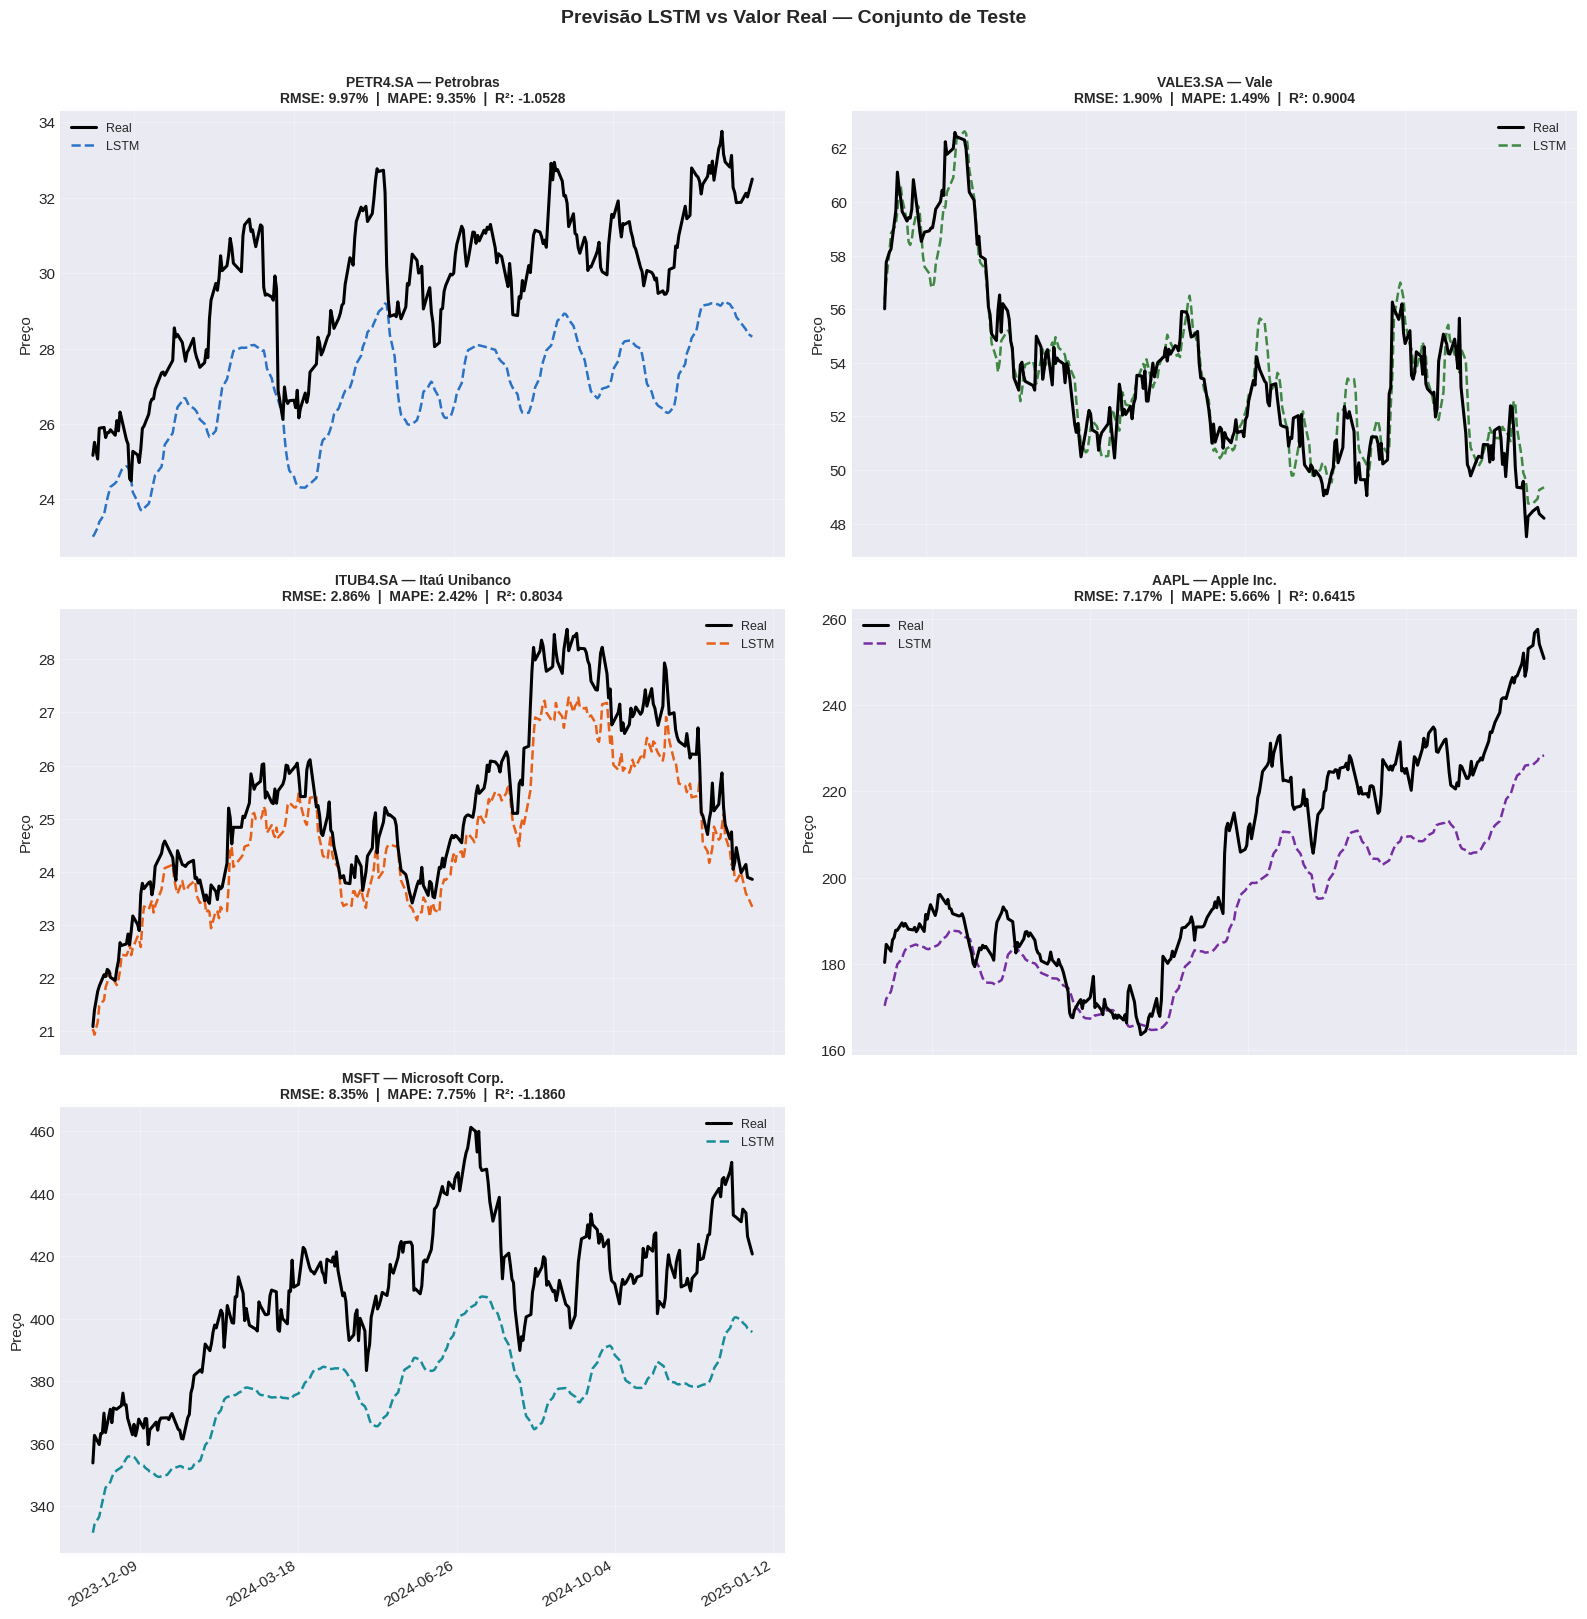

graficos/07_previsao_vs_real.png


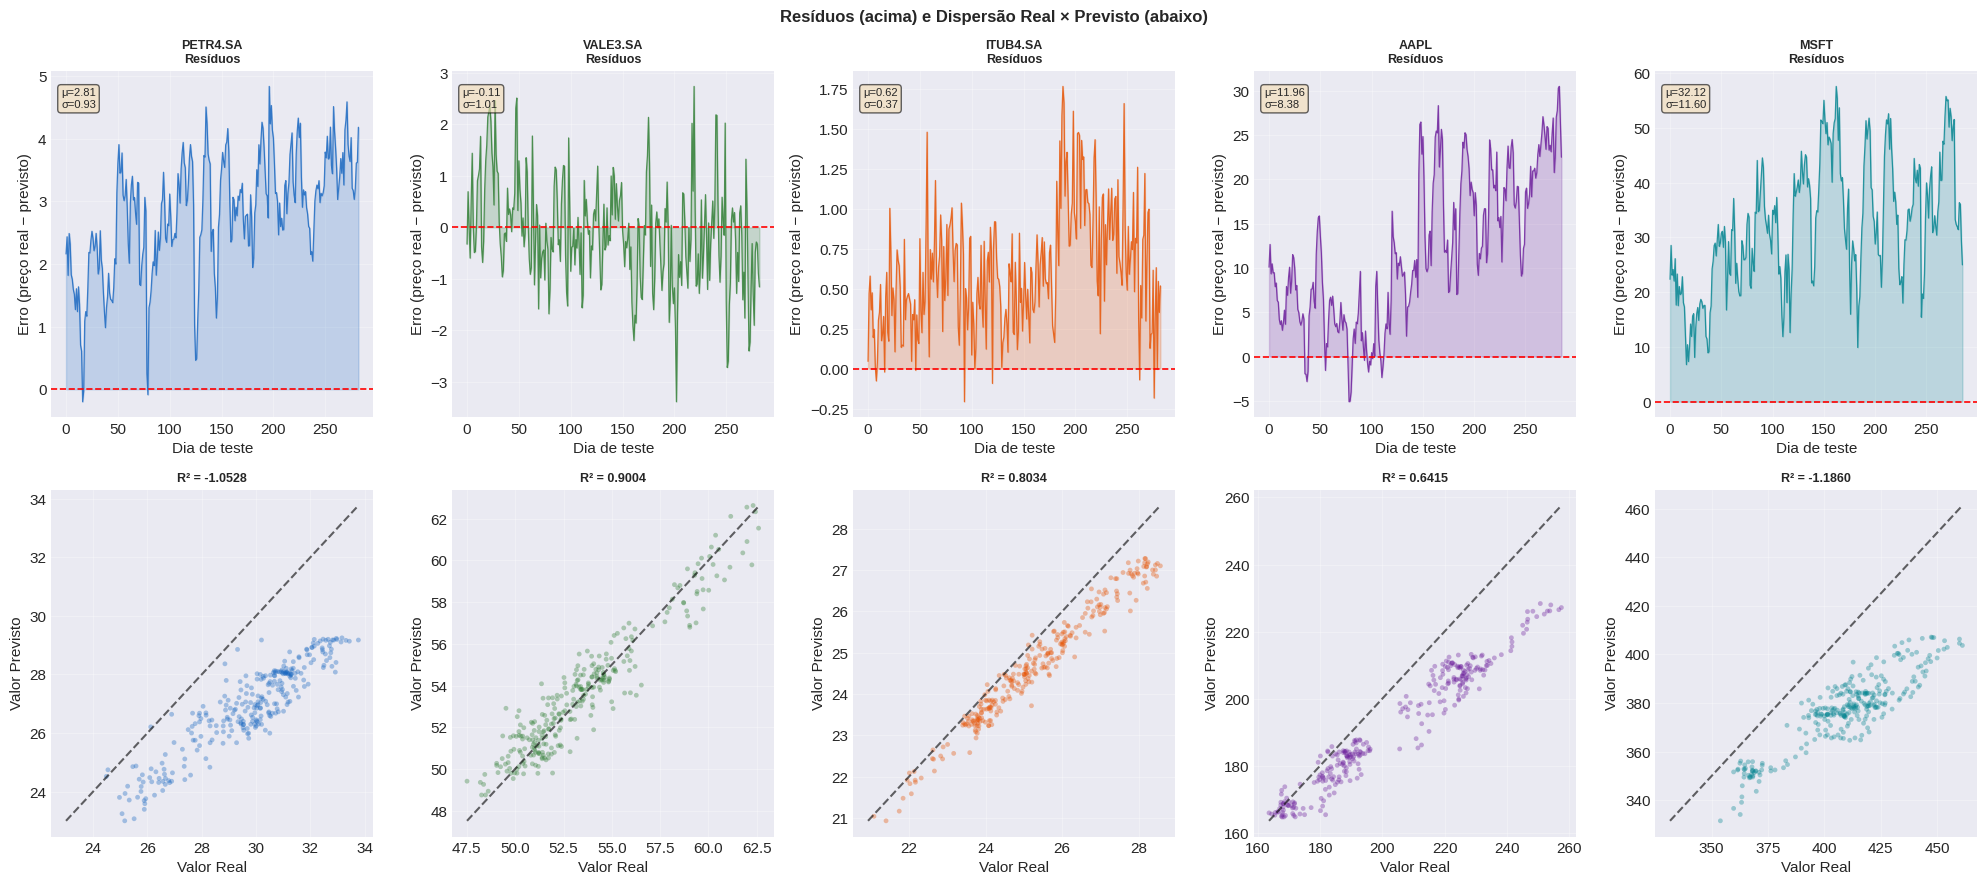

graficos/08_residuos_dispersao.png


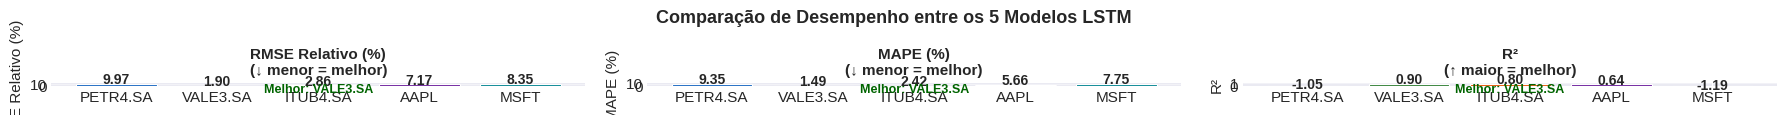

graficos/09_comparacao_metricas.png


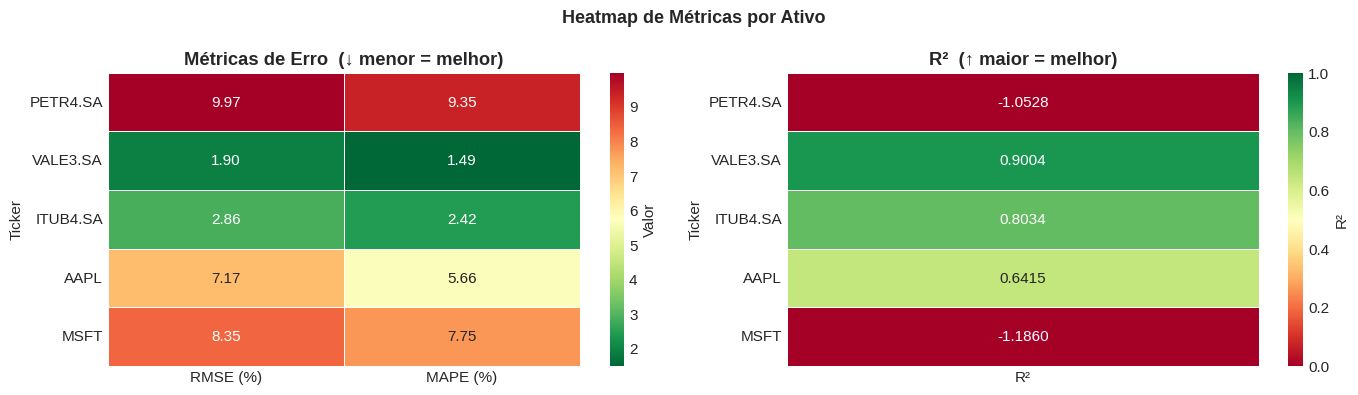

graficos/10_heatmap_metricas.png
Gráficos de avaliação salvos.
resultados/metricas_avaliacao.csv
CSVs de previsões salvas em /resultados/
Módulo 04 — Avaliação concluída!


In [152]:
# Execução
if __name__ == "__main__":
    # 'pipeline' e 'modelos' já foram gerados e estão disponíveis no kernel
    # após a execução dos Módulos 02 e 03. Não é necessário recarregar/reprocessar.

    print("Iniciando avaliação dos modelos...")

    df_metricas, resultados = avaliar_todos(modelos, pipeline)
    gerar_todos_graficos_avaliacao(resultados, pipeline, df_metricas)
    salvar_metricas(df_metricas, resultados)

    print("Módulo 04 — Avaliação concluída!")

In [153]:
## MÓDULO 5 — GERAÇÃO DAS PREVISÕES FUTURAS

In [154]:
# Configurações
DIAS_FUTURO = 30       # dias úteis a prever no futuro
HIST_DIAS   = 90       # dias de histórico exibidos no gráfico
PASTA_GRAF  = "graficos"
PASTA_RES   = "resultados"

ACOES = {
    "PETR4.SA": "Petrobras",
    "VALE3.SA":  "Vale",
    "ITUB4.SA":  "Itaú Unibanco",
    "AAPL":      "Apple Inc.",
    "MSFT":      "Microsoft Corp.",
}

CORES = {
    "PETR4.SA": "#1565C0",
    "VALE3.SA":  "#2E7D32",
    "ITUB4.SA":  "#E65100",
    "AAPL":      "#6A1B9A",
    "MSFT":      "#00838F",
}

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"font.size": 11, "figure.dpi": 100})


In [162]:
# ── Previsão Iterativa ─────────────────────
def prever_futuro_iterativo(ticker:      str,
                             modelo,
                             df_raw:     pd.DataFrame,
                             p:          dict,
                             dias:       int = DIAS_FUTURO
                             ) -> pd.Series:
    """
    Gera previsões futuras pelo método autoregressivo iterativo.

    Algoritmo
    ---------
    Seja J = janela, n = dias_futuro:
      buffer = óltimos J preços normalizados (conhecidos)

      Para t = 1 … n:
        X     = reshape(buffer[-J:], (1, J, n_features))
        pred  = model.predict(X)           ← valor normalizado
        buffer.append(pred)                ← desloca a janela
        previsoes.append(pred)

      previsoes_reais = scaler_y.inverse_transform(previsoes)

    Parâmetros
    ----------
    ticker  : str              — símbolo do ativo
    modelo  : tf.keras.Model   — modelo treinado
    df_raw  : pd.DataFrame     — dados OHLCV originais
    p       : dict             — artefatos do pré-processamento
    dias    : int              — número de dias úteis a prever

    Retorno
    -------
    pd.Series — previsões desnormalizadas indexadas por datas futuras
    """

    janela   = p["janela"]
    scaler_X = p["scaler_X"]
    scaler_y = p["scaler_y"]
    colunas  = p["colunas"]

    # Recriar o DataFrame de features nos dados originais
    df_feat = adicionar_features(df_raw)
    # Garantir mesmas colunas do treino
    df_feat = df_feat[colunas]

    # Normalizar com scaler fitado no treino
    dados_norm = scaler_X.transform(df_feat.values)

    # Buffer inicial: óltimas `janela` linhas normalizadas
    buffer = list(dados_norm[-janela:])      # lista de arrays (n_features,)

    previsoes_norm = []

    for _ in range(dias):
        X = np.array(buffer[-janela:]).reshape(1, janela, len(colunas))
        pred_norm = float(modelo.predict(X, verbose=0)[0, 0])
        previsoes_norm.append(pred_norm)

        # Criar linha fictícia para manter n_features consistente:
        # replica óltima linha normalizada e substitui a posição do Close
        nova_linha = buffer[-1].copy()
        nova_linha[colunas.index("Close")] = pred_norm
        buffer.append(nova_linha)

    # Desnormalizar apenas o Close (usar scaler_y)
    previsoes_reais = scaler_y.inverse_transform(
        np.array(previsoes_norm).reshape(-1, 1)
    ).flatten()

    # Gerar datas úteis futuras
    datas_futuras = pd.bdate_range(
        start=df_raw.index[-1] + pd.Timedelta(days=1),
        periods=dias,
    )

    return pd.Series(previsoes_reais, index=datas_futuras,
                     name="Previsao")


def prever_todos(modelos:    dict,
                  dados_raw:  dict,
                  pipeline:   dict,
                  dias:       int = DIAS_FUTURO) -> dict:
    """
    Gera previsões futuras para todos os ativos.

    Parâmetros
    ----------
    modelos   : dict[ticker, Model]
    dados_raw : dict[ticker, DataFrame]
    pipeline  : dict[ticker, artefatos]
    dias      : int — horizonte de previsão

    Retorno
    -------
    dict[ticker, pd.Series] — previsões por ativo
    """
    print(f"\n{'='*60}")
    print(f"  PREVISÕES FUTURAS — {dias} Dias Úteis")
    print(f"  Método: Iterativo (autoregressivo)")
    print(f"{'='*60}\n")

    previsoes = {}
    resumo    = []

    for ticker in ACOES:
        if ticker not in modelos:
            continue

        prev = prever_futuro_iterativo(
            ticker, modelos[ticker],
            dados_raw[ticker], pipeline[ticker], dias)

        previsoes[ticker] = prev

        ult    = float(dados_raw[ticker]["Close"].iloc[-1])
        fin    = float(prev.iloc[-1])
        minimo = float(prev.min())
        maximo = float(prev.max())
        var    = (fin - ult) / ult * 100
        sinal  = "▲" if var > 0 else "▼"

        resumo.append({
            "Ticker":              ticker,
            "Empresa":             ACOES[ticker],
            "Preço Atual":         round(ult, 2),
            f"Prev. D+{dias}":     round(fin, 2),
            "Mínimo Previsto":     round(minimo, 2),
            "Máximo Previsto":     round(maximo, 2),
            "Variação Est. (%)":   round(var, 2),
            "Tendãncia":           f"{sinal} {var:+.2f}%",
        })

        print(f"  {ticker:12s} | "
              f"Atual: {ult:8.2f}  →  "
              f"D+{dias}: {fin:8.2f}  |  {sinal} {var:+.2f}%")

    df_resumo = pd.DataFrame(resumo).set_index("Ticker")
    print(f"\n{'─'*60}")
    print(df_resumo.to_string())

    return previsoes, df_resumo

In [157]:
# ── Gráficos ───────────────────────────────────────────────
def plot_previsoes_individuais(previsoes:  dict,
                                dados_raw:  dict,
                                dias:       int = DIAS_FUTURO) -> None:
    """
    Subplot por ativo: histórico recente + previsão futura
    com banda de incerteza ±5%.
    """
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, axes = plt.subplots(3, 2, figsize=(16, 16))
    axes = axes.flatten()

    for i, (ticker, cor) in enumerate(CORES.items()):
        if ticker not in previsoes:
            continue

        hist = dados_raw[ticker]["Close"].iloc[-HIST_DIAS:]
        prev = previsoes[ticker]
        ult  = float(hist.iloc[-1])
        fin  = float(prev.iloc[-1])
        var  = (fin - ult) / ult * 100
        sinal = "▲" if var > 0 else "▼"

        # Histórico
        axes[i].plot(hist.index, hist.values,
                     color="#455A64", lw=1.8,
                     label=f"Histórico ({HIST_DIAS}d)", alpha=0.85)

        # Previsão futura
        axes[i].plot(prev.index, prev.values,
                     color=cor, lw=2.5, ls="--",
                     marker="o", markersize=3,
                     label=f"Previsão +{dias}d", zorder=5)

        # Linha de conexão histórico → previsão
        axes[i].plot([hist.index[-1], prev.index[0]],
                     [hist.iloc[-1],  prev.iloc[0]],
                     color=cor, lw=1.5, ls="--", alpha=0.5)

        # Banda de incerteza ±5%
        axes[i].fill_between(
            prev.index,
            prev.values * 0.95,
            prev.values * 1.05,
            alpha=0.18, color=cor, label="Incerteza ±5%")

        # Linha vertical de corte
        axes[i].axvline(hist.index[-1], color="black",
                        ls=":", lw=1.5, alpha=0.5)

        axes[i].set_title(
            f"{ticker} — {ACOES[ticker]}\n"
            f"Atual: {ult:.2f}  |  D+{dias}: {fin:.2f}  "
            f"|  {sinal} {var:+.1f}%",
            fontweight="bold", fontsize=10)
        axes[i].set_ylabel("Preço")
        axes[i].legend(fontsize=8, loc="upper left")
        axes[i].grid(True, alpha=0.3)

        # Formatação do eixo x
        axes[i].xaxis.set_major_formatter(
            mdates.DateFormatter("%b/%y"))
        axes[i].xaxis.set_major_locator(
            mdates.MonthLocator(interval=2))
        fig.autofmt_xdate()

    axes[-1].set_visible(False)
    plt.suptitle(
        f"Previsões Futuras — Próximos {dias} Dias Úteis\n"
        "Linha tracejada = LSTM  |  Banda cinza = histórico",
        fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = os.path.join(
        PASTA_GRAF, "11_previsoes_futuras_individuais.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{path}")



In [158]:
def plot_previsoes_comparativas(previsoes:  dict,
                                 dados_raw:  dict,
                                 dias:       int = DIAS_FUTURO) -> None:
    """
    Painel único: todas as previsões em base 100
    (100 = preço atual de cada ativo).
    Facilita comparação relativa entre ativos.
    """
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, ax = plt.subplots(figsize=(15, 7))

    for ticker, cor in CORES.items():
        if ticker not in previsoes:
            continue
        prev  = previsoes[ticker]
        base  = float(dados_raw[ticker]["Close"].iloc[-1])
        b100  = prev / base * 100
        ax.plot(b100.index, b100.values,
                color=cor, lw=2.5,
                marker="o", markersize=4,
                label=f"{ticker} — {ACOES[ticker]}")

    ax.axhline(100, color="black", ls=":",
               lw=1.5, alpha=0.5, label="Preço atual = 100")
    ax.fill_between(
        b100.index, 95, 105,
        alpha=0.06, color="gray",
        label="Faixa ±5%")

    ax.set_title(
        f"Previsões Futuras Comparativas — Base 100 (hoje)\n"
        f"Próximos {dias} dias úteis | "
        f"100 = preço atual de cada ativo",
        fontsize=13, fontweight="bold")
    ax.set_ylabel("Índice  (100 = preço atual)")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%b"))
    fig.autofmt_xdate()

    plt.tight_layout()
    path = os.path.join(
        PASTA_GRAF, "12_previsoes_comparativas_base100.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"{path}")


In [159]:
def salvar_previsoes(previsoes: dict,
                      df_resumo: pd.DataFrame,
                      pasta:     str = PASTA_RES) -> None:
    """Salva cada previsão em CSV e o resumo consolidado."""
    os.makedirs(pasta, exist_ok=True)

    for ticker, prev in previsoes.items():
        safe = ticker.replace(".", "_")
        path = os.path.join(pasta, f"previsao_futura_{safe}.csv")
        prev.to_frame(name="Previsao").to_csv(path)

    path_r = os.path.join(pasta, "resumo_previsoes_futuras.csv")
    df_resumo.to_csv(path_r)
    print(f"CSVs salvos em /{pasta}/")


Iniciando geração das previsões futuras...

  PREVISÕES FUTURAS — 30 Dias Úteis
  Método: Iterativo (autoregressivo)

  PETR4.SA     | Atual:    32.50  →  D+30:    28.01  |  ▼ -13.80%
  VALE3.SA     | Atual:    48.20  →  D+30:    48.96  |  ▲ +1.59%
  ITUB4.SA     | Atual:    23.86  →  D+30:    23.34  |  ▼ -2.19%
  AAPL         | Atual:   250.83  →  D+30:   223.25  |  ▼ -11.00%
  MSFT         | Atual:   420.76  →  D+30:   382.44  |  ▼ -9.11%

────────────────────────────────────────────────────────────
                  Empresa  Preço Atual  Prev. D+30  Mínimo Previsto  Máximo Previsto  Variação Est. (%)  Tendãncia
Ticker                                                                                                            
PETR4.SA        Petrobras        32.50       28.01            28.01            28.31             -13.80  ▼ -13.80%
VALE3.SA             Vale        48.20       48.96            48.69            49.38               1.59   ▲ +1.59%
ITUB4.SA    Itaú Unibanco        

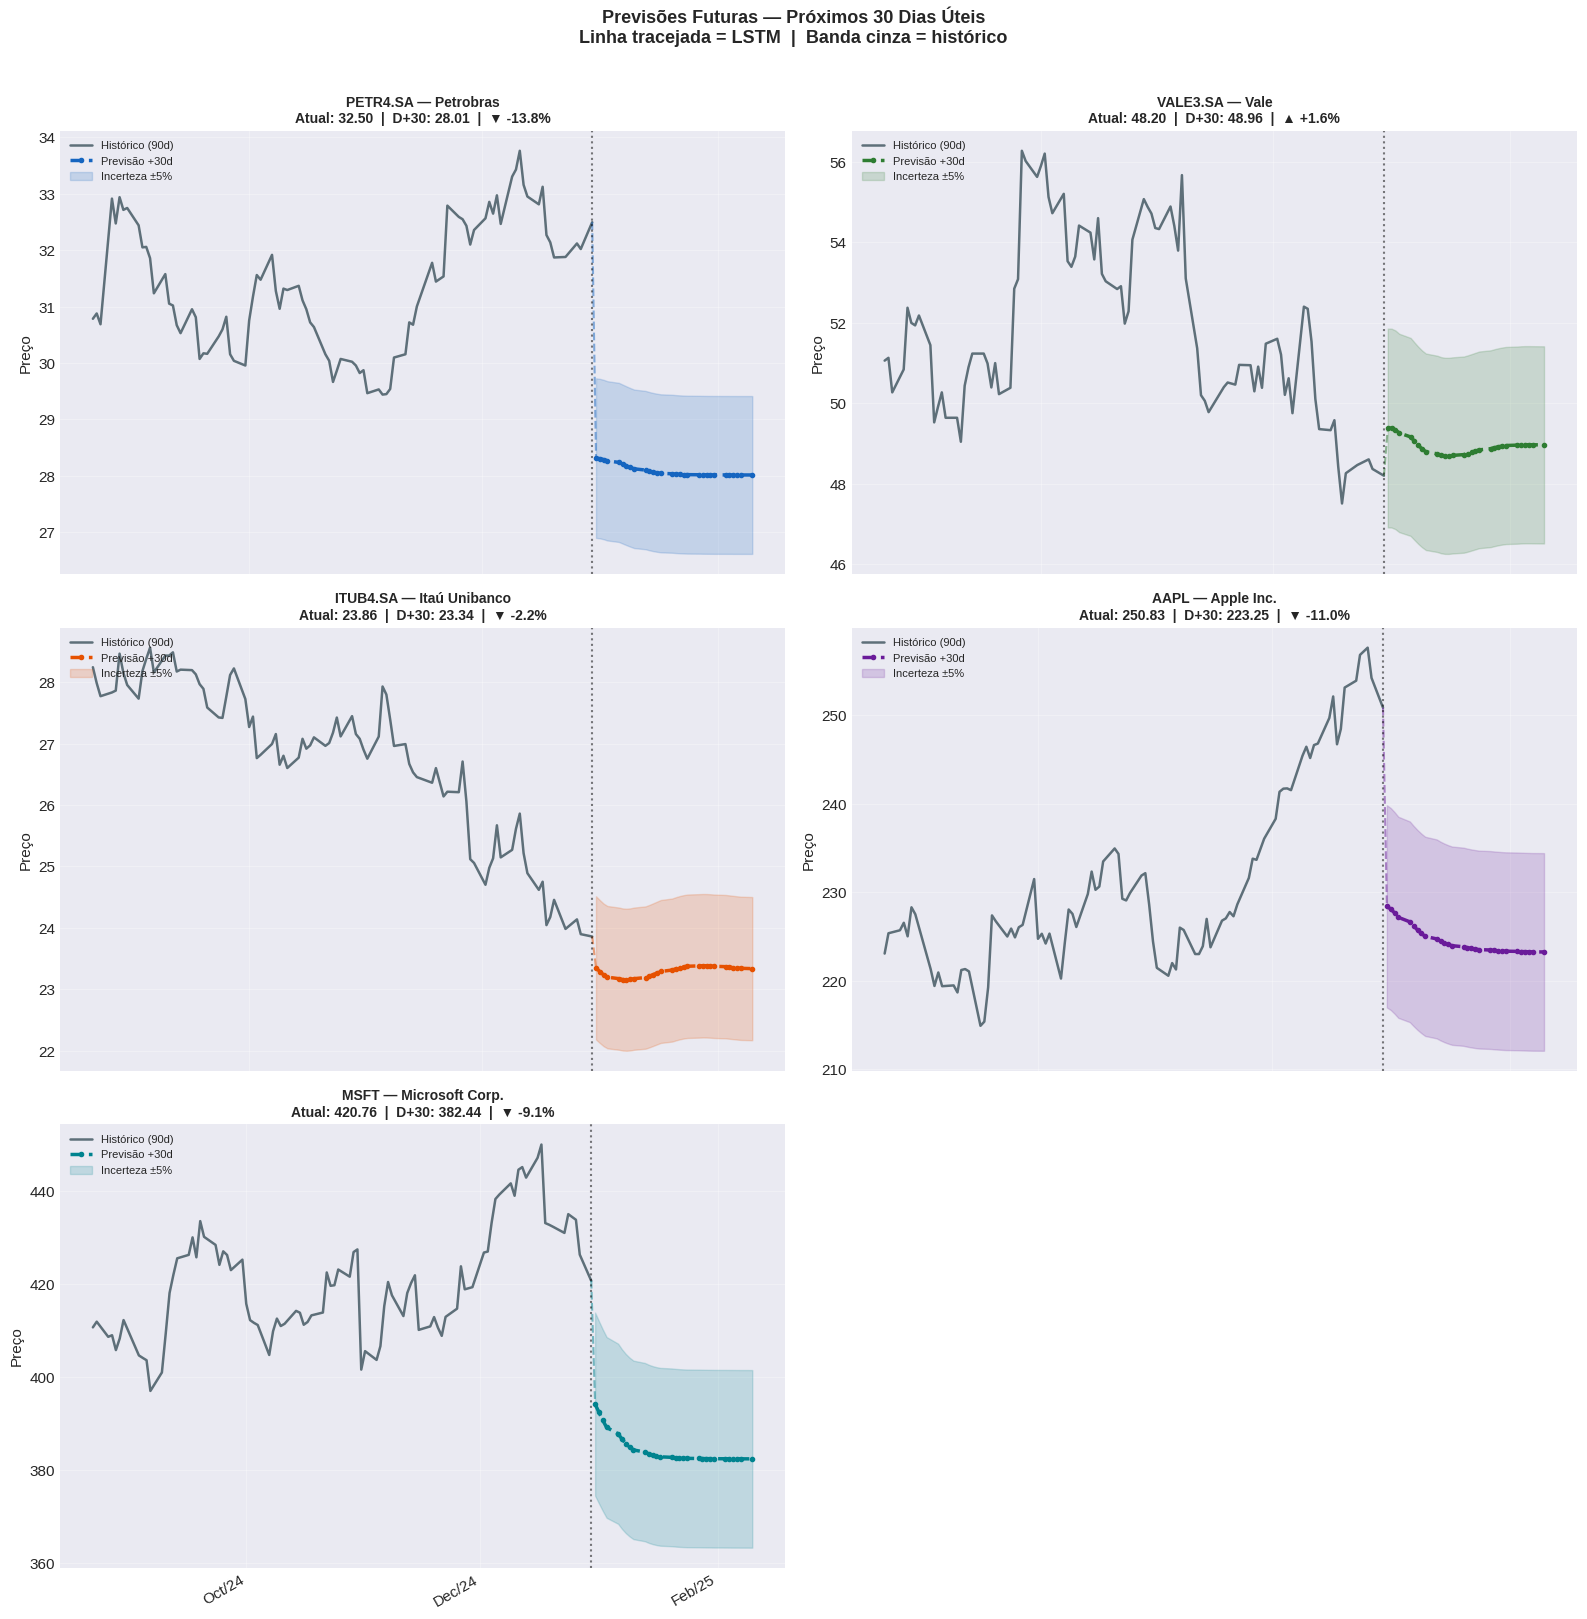

graficos/11_previsoes_futuras_individuais.png


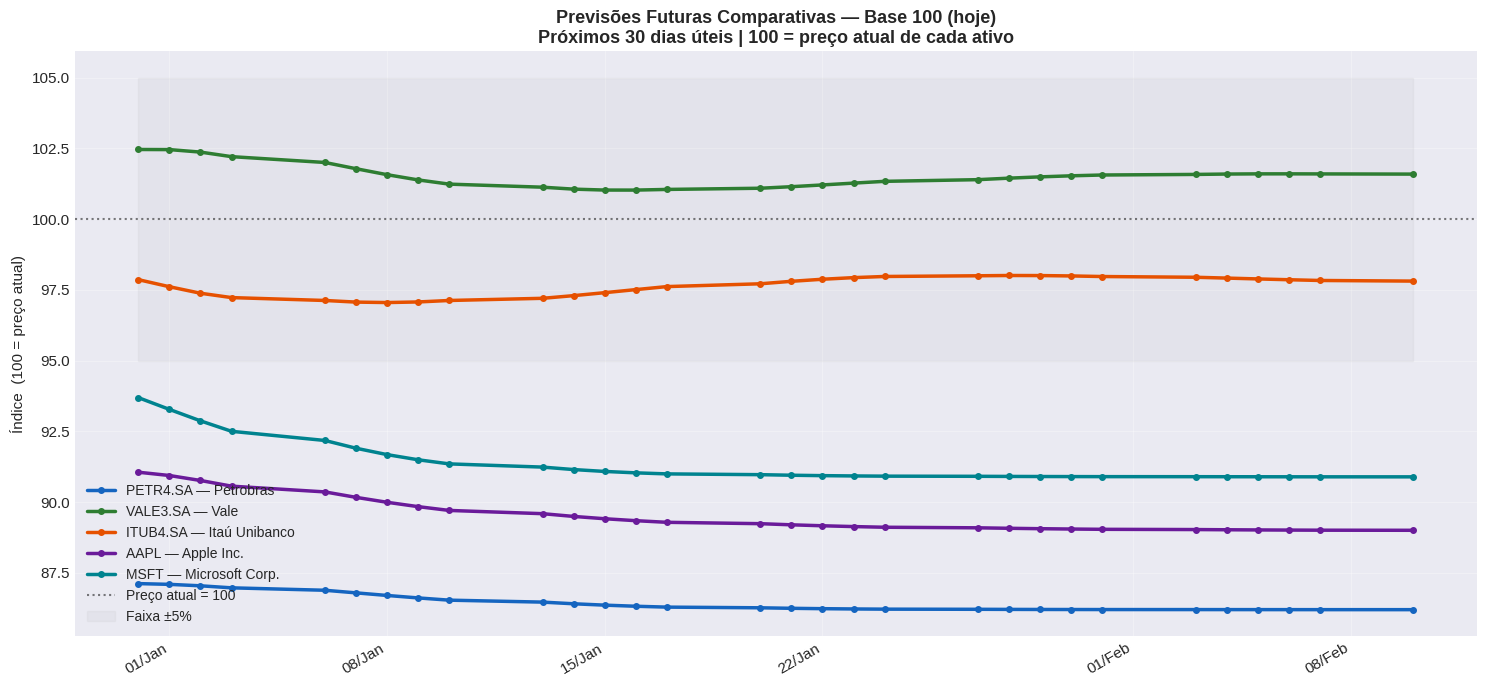

graficos/12_previsoes_comparativas_base100.png
CSVs salvos em /resultados/
Módulo 05 — Previsões geradas!


In [163]:
# Execução
if __name__ == "__main__":
    # As variáveis 'dados_raw', 'pipeline' e 'modelos' já foram geradas
    # e estão disponíveis no kernel após a execução dos Módulos 01, 02 e 03.
    # Não é necessário recarregar/reprocessar os dados ou treinar os modelos novamente.

    print("Iniciando geração das previsões futuras...")

    previsoes, df_resumo = prever_todos(
        modelos, dados_raw, pipeline, DIAS_FUTURO)

    print("\nGerando gráficos...")
    plot_previsoes_individuais(previsoes, dados_raw, DIAS_FUTURO)
    plot_previsoes_comparativas(previsoes, dados_raw, DIAS_FUTURO)
    salvar_previsoes(previsoes, df_resumo)

    print("Módulo 05 — Previsões geradas!")

In [164]:
## MÓDULO 6 — ANÁLISE EXPLORATÓRIA E VISUALIZAÇÕES

In [165]:
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update({"font.size": 11, "figure.dpi": 100})

PASTA_GRAF = "graficos"

ACOES = {
    "PETR4.SA": "Petrobras",
    "VALE3.SA":  "Vale",
    "ITUB4.SA":  "Itaú Unibanco",
    "AAPL":      "Apple Inc.",
    "MSFT":      "Microsoft Corp.",
}

CORES = {
    "PETR4.SA": "#1565C0",
    "VALE3.SA":  "#2E7D32",
    "ITUB4.SA":  "#E65100",
    "AAPL":      "#6A1B9A",
    "MSFT":      "#00838F",
}


In [166]:
def plot_desempenho_base100(dados: dict) -> None:
    """Desempenho relativo de todos os ativos em base 100."""
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, ax = plt.subplots(figsize=(15, 6))
    for ticker, cor in CORES.items():
        if ticker not in dados:
            continue
        s = dados[ticker]["Close"]
        ax.plot(s.index, s / s.iloc[0] * 100,
                label=f"{ticker} — {ACOES[ticker]}",
                color=cor, lw=1.8)
    ax.axhline(100, color="black", ls=":", alpha=0.4, lw=1)
    ax.set_title("Desempenho Comparativo — Base 100 (Jan/2019)",
                 fontsize=14, fontweight="bold")
    ax.set_ylabel("Índice")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "01_desempenho_base100.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"{path}")


In [167]:
def plot_precos_bollinger(dados: dict) -> None:
    """Preço de fechamento + MM20 + Bollinger Bands."""
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    axes = axes.flatten()
    for i, (ticker, cor) in enumerate(CORES.items()):
        if ticker not in dados:
            continue
        cls  = dados[ticker]["Close"]
        mm20 = cls.rolling(20).mean()
        std  = cls.rolling(20).std()
        axes[i].plot(cls.index, cls, color=cor, lw=1.4,
                     label="Fechamento")
        axes[i].plot(mm20.index, mm20, "k--", lw=1.1,
                     alpha=0.7, label="MM20")
        axes[i].fill_between(mm20.index,
                              mm20 - 2*std, mm20 + 2*std,
                              alpha=0.12, color=cor,
                              label="Bollinger ±2σ")
        axes[i].set_title(f"{ticker} — {ACOES[ticker]}",
                           fontweight="bold")
        axes[i].set_ylabel("Preço")
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_visible(False)
    plt.suptitle("Preço + MM20 + Bollinger Bands",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "02_precos_bollinger.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{path}")


In [170]:
def plot_retornos_correlacao(dados: dict) -> None:
    """Distribuição dos retornos diários e matriz de correlação."""
    os.makedirs(PASTA_GRAF, exist_ok=True)
    retornos = pd.DataFrame({
        t: dados[t]["Close"].pct_change() * 100
        for t in ACOES if t in dados
    }).dropna()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    for ticker, cor in CORES.items():
        if ticker in retornos.columns:
            axes[0].hist(retornos[ticker], bins=80,
                         alpha=0.4, color=cor,
                         label=ticker, density=True)
    axes[0].axvline(0, color="black", lw=1.5, ls="--")
    axes[0].set_title("Distribuição Retornos Diários (%)",
                       fontweight="bold")
    axes[0].set_xlabel("Retorno (%)")
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    corr = retornos.corr()
    sns.heatmap(corr, annot=True, fmt=".2f",
                cmap="RdYlGn", center=0, ax=axes[1],
                linewidths=0.5, square=True,
                vmin=-1, vmax=1)
    axes[1].set_title("Correlação dos Retornos",
                       fontweight="bold")
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "03_retornos_correlacao.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"{path}")

Gerando gráficos de Análise Exploratória e Visualizações...


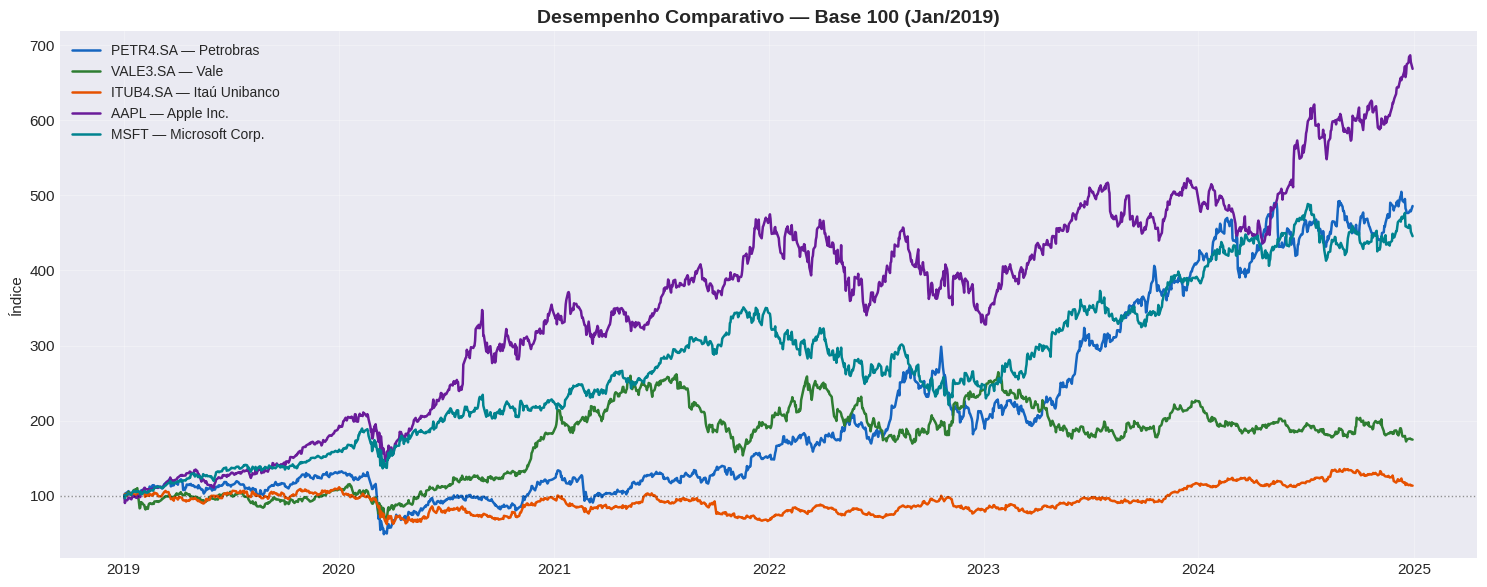

graficos/01_desempenho_base100.png


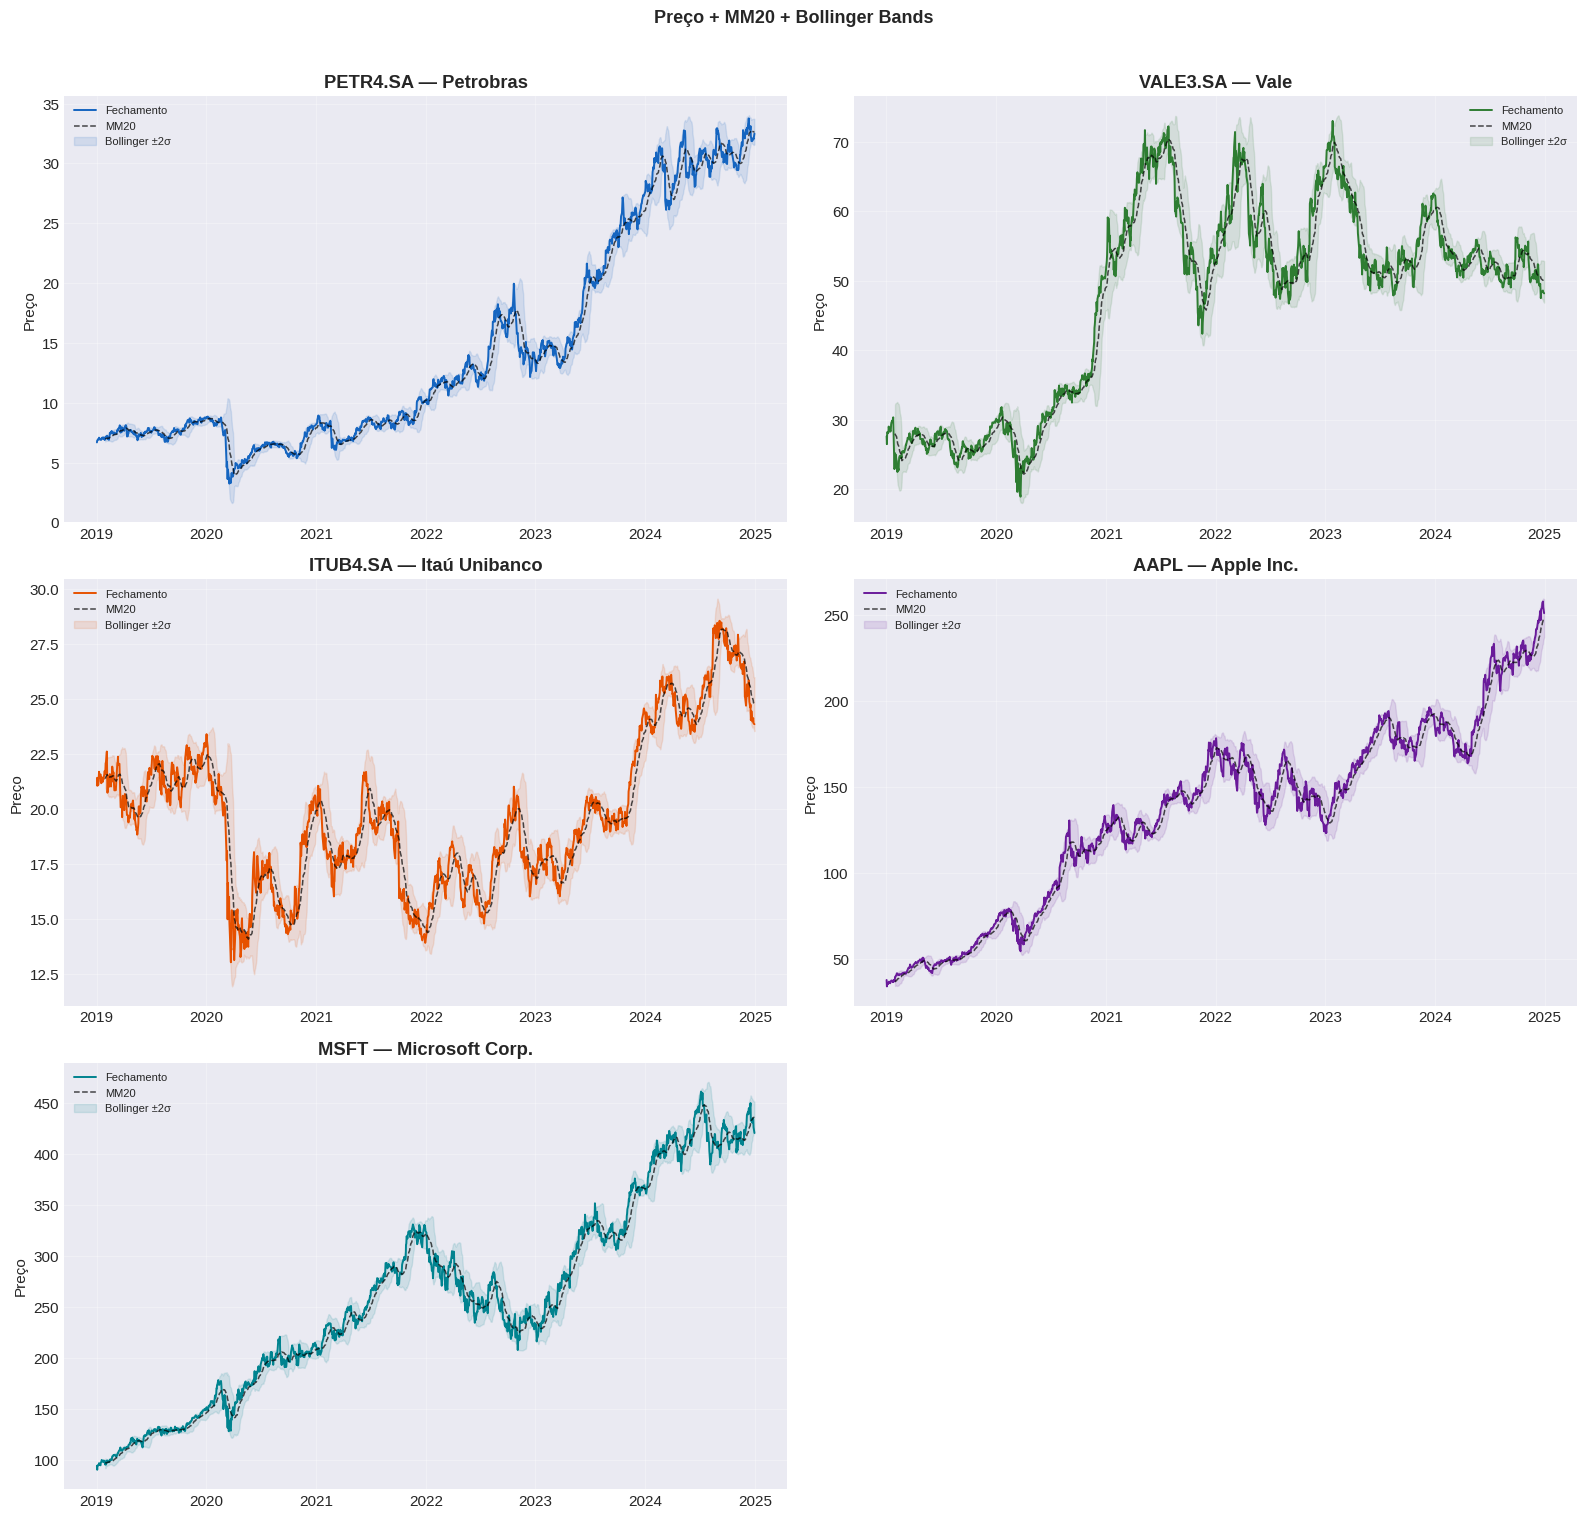

graficos/02_precos_bollinger.png


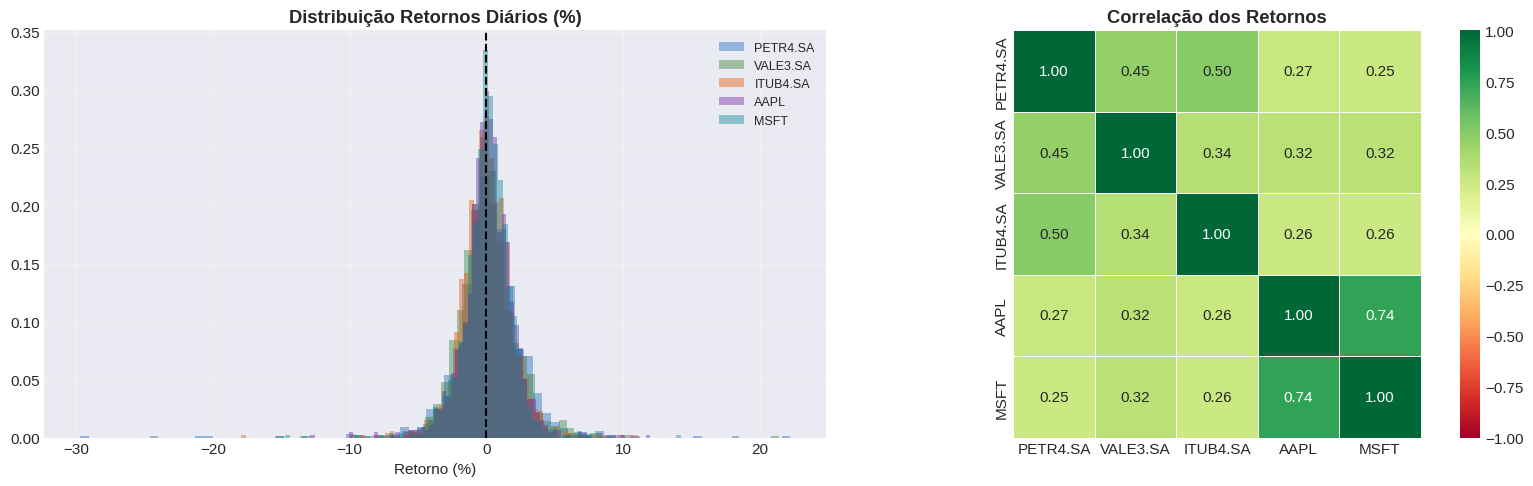

graficos/03_retornos_correlacao.png
Módulo 06 — Análise Exploratória e Visualizações concluído!


In [173]:
# Execução das funções de visualização do Módulo 6
if __name__ == "__main__":
    print("Gerando gráficos de Análise Exploratória e Visualizações...")

    # 'dados_raw' é o DataFrame com os dados brutos carregados no Módulo 1.
    # Ele é usado pelas funções de plotagem.
    plot_desempenho_base100(dados_raw)
    plot_precos_bollinger(dados_raw)
    plot_retornos_correlacao(dados_raw)

    print("Módulo 06 — Análise Exploratória e Visualizações concluído!")

In [175]:
def plot_volatilidade(dados: dict) -> None:
    """Volatilidade histórica anualizada — janela 21 dias."""
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, ax = plt.subplots(figsize=(15, 5))
    for ticker, cor in CORES.items():
        if ticker not in dados:
            continue
        ret = dados[ticker]["Close"].pct_change()
        vol = ret.rolling(21).std() * np.sqrt(252) * 100
        ax.plot(vol.index, vol, color=cor,
                lw=1.4, label=ticker, alpha=0.85)
    ax.set_title("Volatilidade Histórica Anualizada (janela 21d %)",
                 fontsize=13, fontweight="bold")
    ax.set_ylabel("Volatilidade Anualizada (%)")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "04_volatilidade_historica.png")
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"{path}")


In [176]:
def plot_divisao_treino_teste(dados: dict, pipeline: dict) -> None:
    """Gráfico da divisão cronológica treino / teste."""
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten()
    for i, (ticker, cor) in enumerate(CORES.items()):
        if ticker not in pipeline or ticker not in dados:
            continue
        p     = pipeline[ticker]
        df    = dados[ticker]
        corte = p["janela"] + p["n_treino"]
        axes[i].plot(df.index[:corte],
                     df["Close"].iloc[:corte],
                     color=cor, lw=1.8, label="Treino")
        axes[i].plot(df.index[corte:],
                     df["Close"].iloc[corte:],
                     color="#D32F2F", lw=1.8, label="Teste")
        axes[i].axvline(df.index[corte], color="black",
                        ls="--", lw=1.5, alpha=0.6)
        axes[i].set_title(
            f"{ticker}  |  Treino: {p['X_treino'].shape[0]}  "
            f"Teste: {p['X_teste'].shape[0]}",
            fontweight="bold", fontsize=10)
        axes[i].set_ylabel("Preço")
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_visible(False)
    plt.suptitle("Divisão Temporal Treino / Teste (sem shuffle)",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "05_divisao_treino_teste.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{path}")


In [178]:
def plot_curvas_aprendizado(historicos: dict) -> None:
    """Curvas de loss (treino e validação) por ativo."""
    os.makedirs(PASTA_GRAF, exist_ok=True)
    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    axes = axes.flatten()
    for i, (ticker, cor) in enumerate(CORES.items()):
        if ticker not in historicos:
            continue
        h  = historicos[ticker].history
        ep = range(1, len(h["loss"]) + 1)
        axes[i].plot(ep, h["loss"],     color=cor,
                     lw=2, label="Treino")
        axes[i].plot(ep, h["val_loss"], color=cor,
                     lw=2, ls="--", alpha=0.7, label="Validação")
        melhor = int(np.argmin(h["val_loss"])) + 1
        axes[i].axvline(melhor, color="red", ls=":",
                        lw=1.2, label=f"Melhor: {melhor}ª")
        axes[i].set_title(f"{ticker} — Loss por Época",
                           fontweight="bold")
        axes[i].set_xlabel("Época")
        axes[i].set_ylabel("MSE")
        axes[i].set_yscale("log")
        axes[i].legend(fontsize=8)
        axes[i].grid(True, alpha=0.3)
    axes[-1].set_visible(False)
    plt.suptitle("Curvas de Aprendizado — LSTM por Ação",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    path = os.path.join(PASTA_GRAF, "06_curvas_aprendizado.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"{path}")


  Gerando gráficos de análise exploratória...


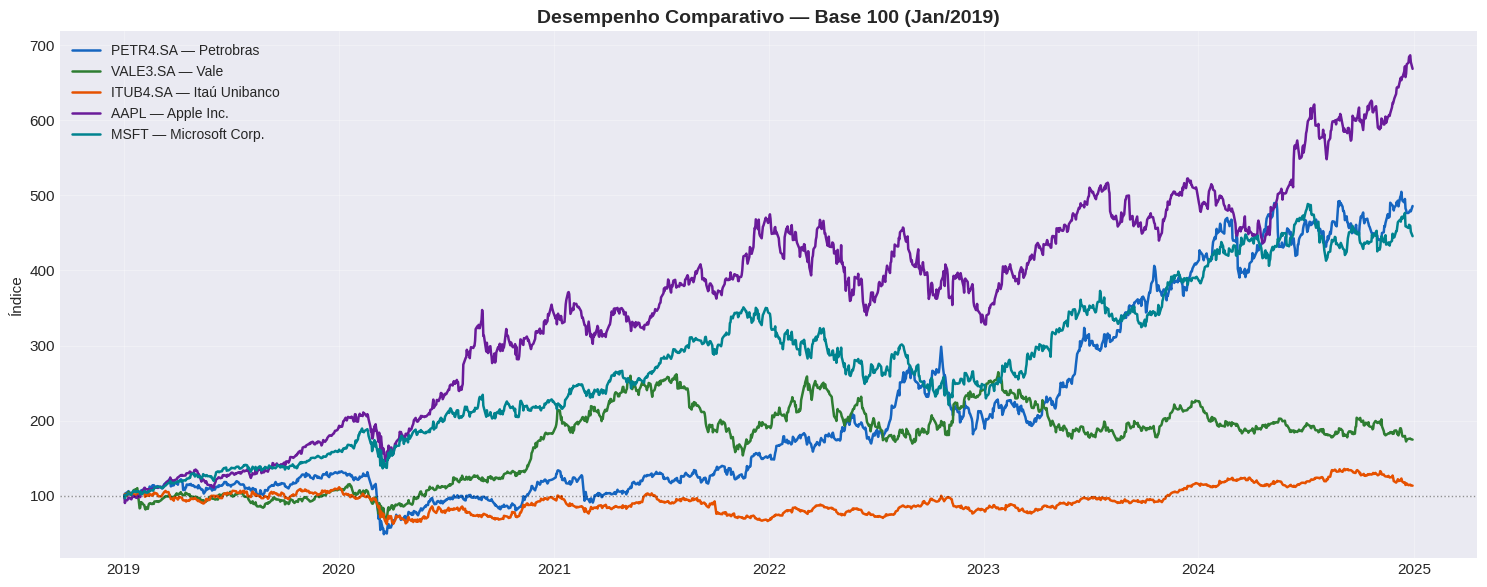

graficos/01_desempenho_base100.png


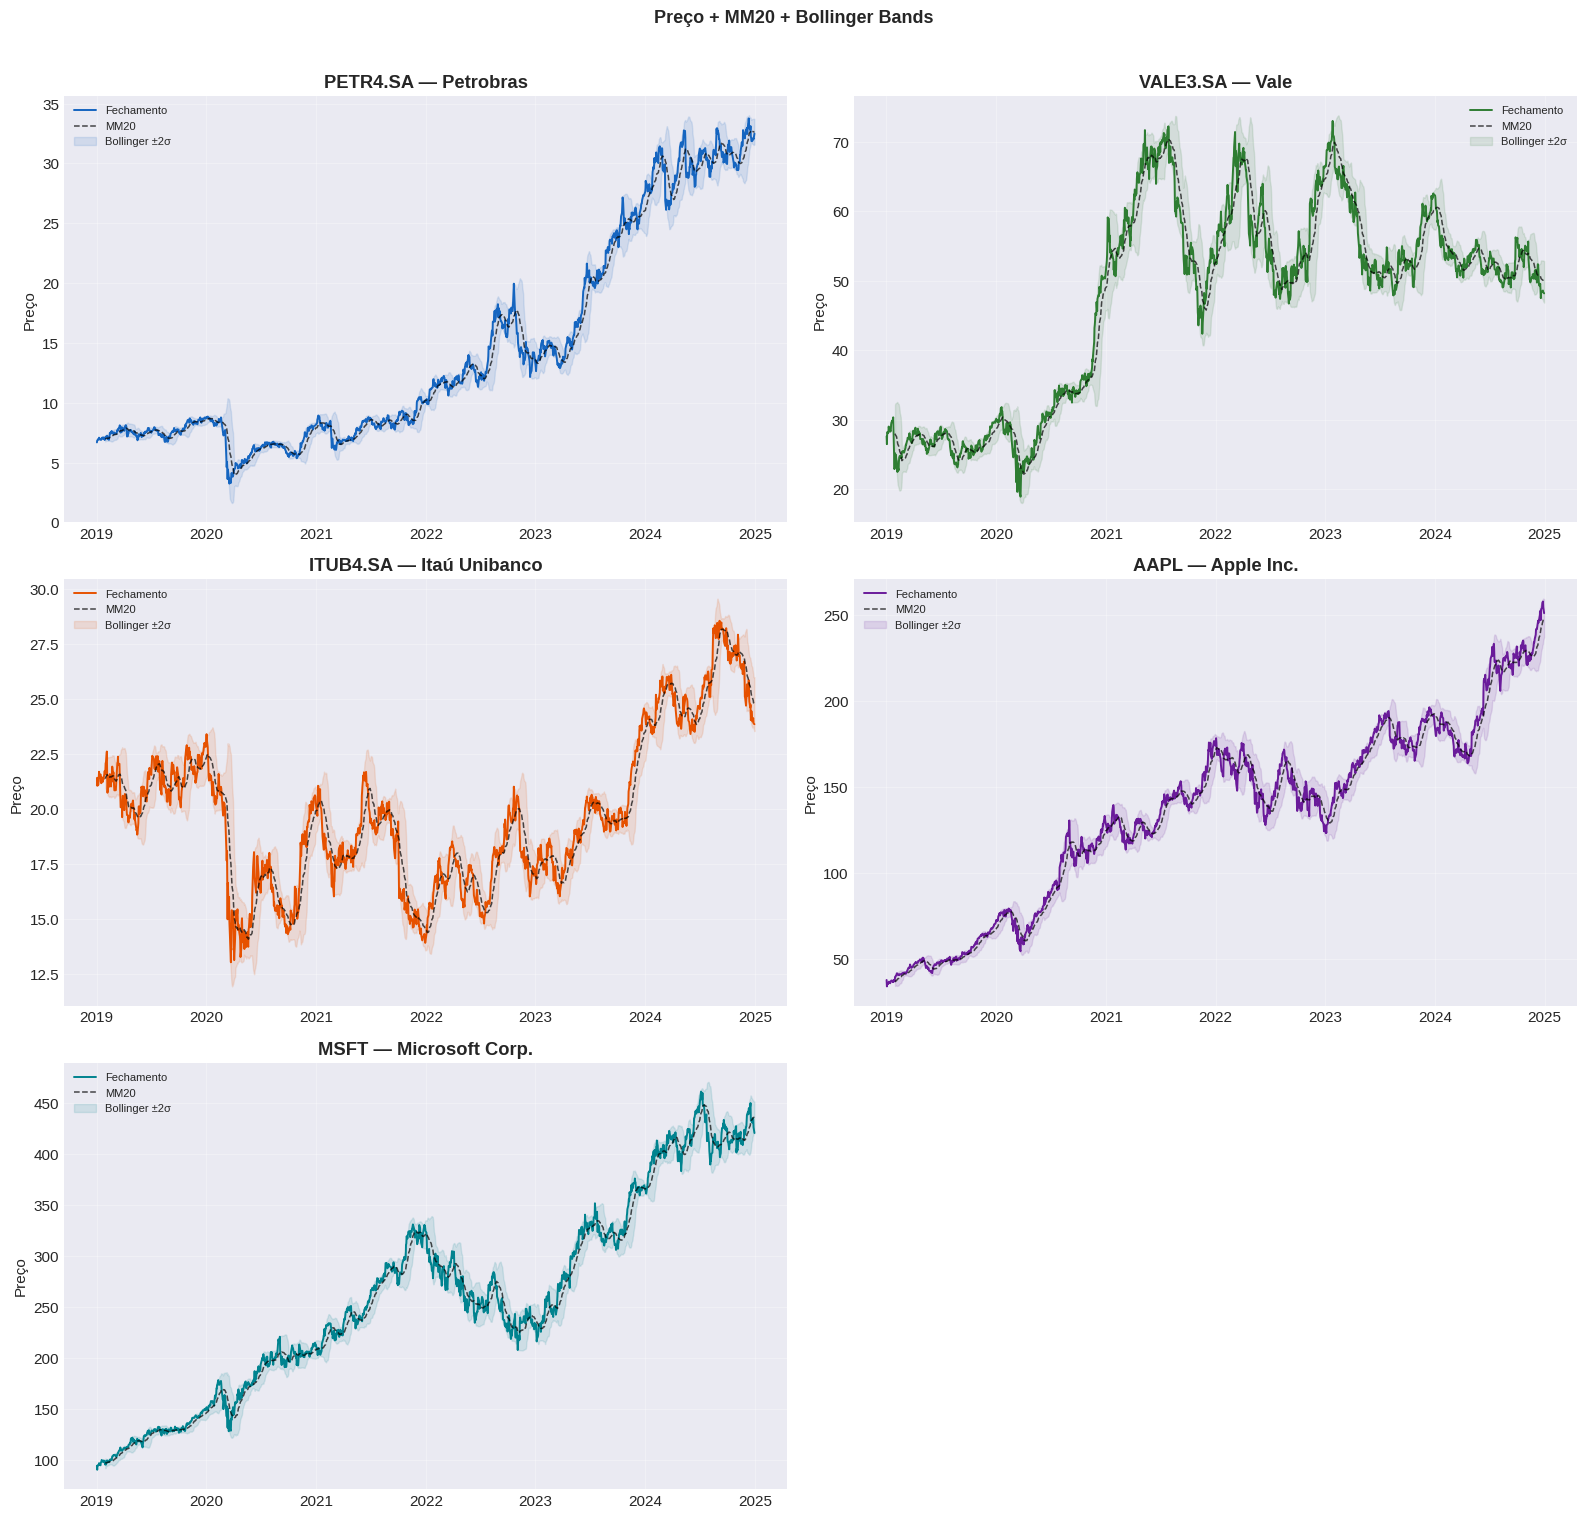

graficos/02_precos_bollinger.png


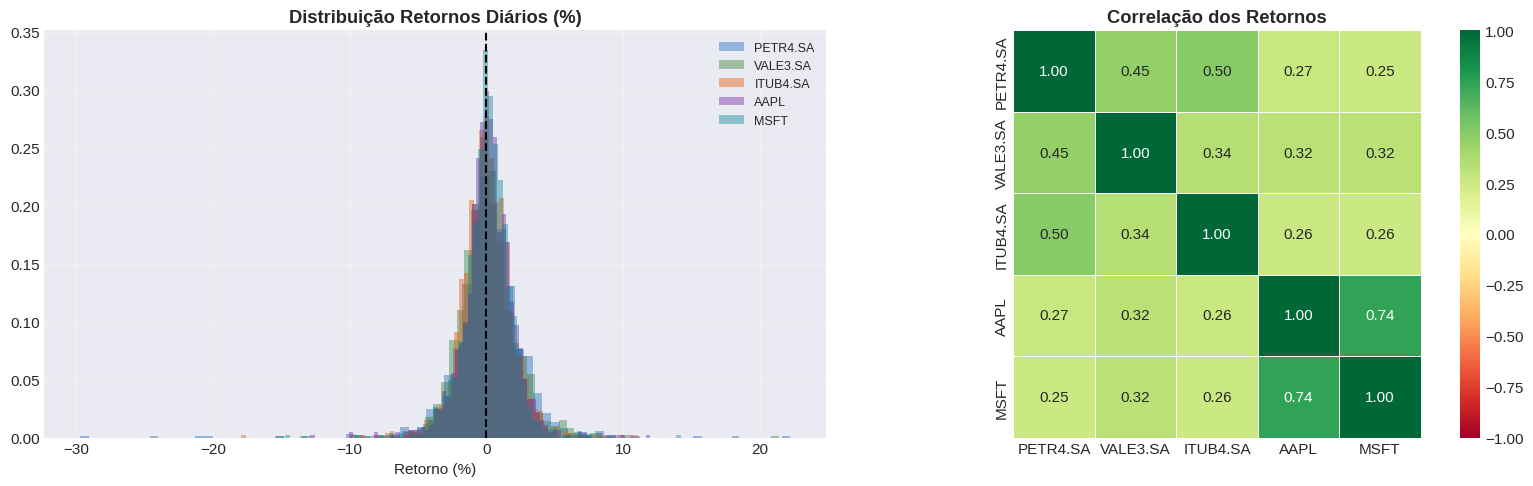

graficos/03_retornos_correlacao.png


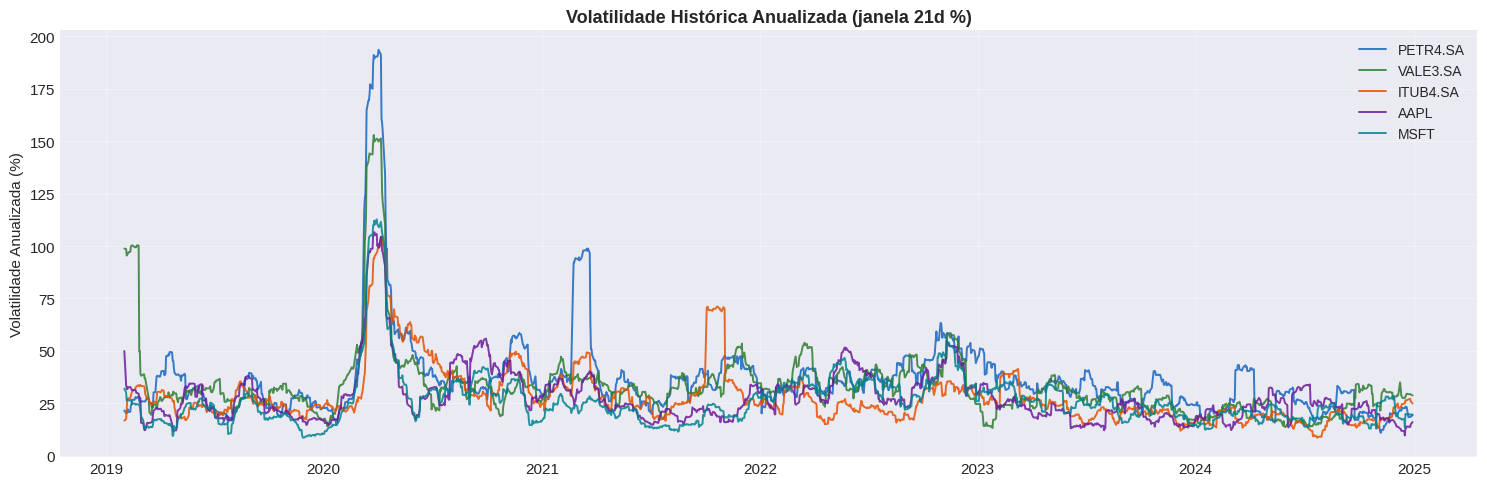

graficos/04_volatilidade_historica.png
Módulo 06 — Visualizações EDA concluídas!


In [180]:
def gerar_todas_eda(dados: dict) -> None:
    """Gera apenas os gráficos de EDA (sem pipeline)."""
    print("\n  Gerando gráficos de análise exploratória...")
    plot_desempenho_base100(dados)
    plot_precos_bollinger(dados)
    plot_retornos_correlacao(dados)
    plot_volatilidade(dados)


if __name__ == "__main__":
    # As variáveis 'dados_raw', 'ACOES' e 'PASTA_DADOS' já foram geradas
    # e estão disponíveis no kernel após a execução do Módulo 01.
    # Não é necessário recarregar os dados.
    dados = dados_raw # Usar os dados brutos já carregados
    gerar_todas_eda(dados)
    print("Módulo 06 — Visualizações EDA concluídas!")

# Previsão de Séries Temporais Financeiras com LSTM

> Projeto acadêmico de aprendizado de máquina para previsão de preços de ações  
> utilizando redes neurais Long Short-Term Memory (LSTM).

![Python](https://img.shields.io/badge/Python-3.10%2B-blue?logo=python)
![TensorFlow](https://img.shields.io/badge/TensorFlow-2.13%2B-orange?logo=tensorflow)
![yfinance](https://img.shields.io/badge/yfinance-0.2%2B-green)
![scikit-learn](https://img.shields.io/badge/scikit--learn-1.3%2B-orange)
![License](https://img.shields.io/badge/License-MIT-lightgrey)

---

## Sumário

1. [Objetivo](#-objetivo)
2. [Critérios de Avaliação Atendidos](#-critérios-de-avaliação-atendidos)
3. [Estrutura do Repositório](#-estrutura-do-repositório)
4. [Ativos Analisados](#-ativos-analisados)
5. [Caracterização do Problema — Séries Temporais](#-caracterização-do-problema--séries-temporais)
6. [Dados Financeiros — Coleta e Justificativa](#-dados-financeiros--coleta-e-justificativa)
7. [Pré-processamento das Sequências Temporais](#-pré-processamento-das-sequências-temporais)
8. [Modelo Neural — Arquitetura LSTM](#-modelo-neural--arquitetura-lstm)
9. [Avaliação do Desempenho](#-avaliação-do-desempenho)
10. [Organização do Código](#-organização-do-código)
11. [Como Executar](#-como-executar)
12. [Resultados Esperados](#-resultados-esperados)
13. [Tecnologias](#-tecnologias)
14. [Limitações e Melhorias Futuras](#-limitações-e-melhorias-futuras)

---

## Objetivo

Desenvolver um sistema completo de previsão de preços de ações utilizando  
redes neurais LSTM, cobrindo todo o pipeline de ciência de dados:  
coleta → pré-processamento → modelagem → avaliação → previsão futura.

---

## Critérios de Avaliação Atendidos

| # | Critério | Como foi atendido | Módulo |
|---|----------|-------------------|--------|
| 1 | Correta caracterização do problema de séries temporais | Definição formal de séries temporais financeiras, autocorrelação, não-estacionariedade, janela deslizante e fundamentação do split cronológico | [`02_preprocessamento.py`](#-pré-processamento-das-sequências-temporais) |
| 2 | Uso adequado dos dados financeiros | yfinance com `auto_adjust=True`, 6 anos de dados, 5 ativos de setores e mercados distintos, cache em CSV | [`01_coleta_dados.py`](#-dados-financeiros--coleta-e-justificativa) |
| 3 | Preparação correta das sequências temporais | Scaler fitado **apenas no treino**, janela de 60 dias, split cronológico **sem shuffle**, reshape 3D para LSTM | [`02_preprocessamento.py`](#-pré-processamento-das-sequências-temporais) |
| 4 | Escolha e implementação do modelo neural | Arquitetura LSTM 128→64 com justificativa detalhada, Dropout, L2, 3 callbacks de controle | [`03_modelo.py`](#-modelo-neural--arquitetura-lstm) |
| 5 | Avaliação coerente do desempenho | 5 métricas complementares (RMSE, RMSE%, MAE, MAPE, R²) avaliadas **exclusivamente no conjunto de teste** | [`04_avaliacao.py`](#-avaliação-do-desempenho) |
| 6 | Clareza e organização do código | 6 módulos independentes, `config.py` central, docstrings completas em todas as funções, comentários explicativos | [Todos os módulos](#-organização-do-código) |
| 7 | Qualidade da documentação | README com fundamentos teóricos, arquitetura, métricas, exemplos e instruções detalhadas | Este arquivo |

---

## Estrutura do Repositório

```
previsao-acoes-lstm/
│
├── previsao_acoes_lstm.ipynb   # Notebook orquestrador — executa os 6 módulos em sequência
│
├── src/
│   ├── config.py               # Configurações centrais (ativos, datas, hiperparâmetros)
│   ├── 01_coleta_dados.py      # Coleta via yfinance + cache em CSV
│   ├── 02_preprocessamento.py  # Feature engineering + normalização + janela deslizante
│   ├── 03_modelo.py            # Arquitetura LSTM + treinamento + callbacks
│   ├── 04_avaliacao.py         # Métricas + gráficos de avaliação
│   ├── 05_previsoes.py         # Previsão futura (30 dias úteis)
│   └── 06_visualizacoes.py     # Gráficos EDA + curvas de aprendizado
│
├── requirements.txt            # Dependências com versões mínimas
├── README.md                   # Esta documentação
│
├── dados/                      # (gerado automaticamente)
│   ├── PETR4_SA.csv
│   ├── VALE3_SA.csv
│   ├── ITUB4_SA.csv
│   ├── AAPL.csv
│   ├── MSFT.csv
│   └── _resumo_coleta.csv
│
├── modelos/                    # (gerado automaticamente)
│   ├── lstm_PETR4_SA.keras
│   ├── lstm_VALE3_SA.keras
│   ├── lstm_ITUB4_SA.keras
│   ├── lstm_AAPL.keras
│   ├── lstm_MSFT.keras
│   ├── log_treinamento.csv
│   └── historico_<TICKER>.csv  # curvas loss/val_loss por ativo
│
├── graficos/                   # (gerado automaticamente)
│   ├── 01_desempenho_base100.png
│   ├── 02_precos_bollinger.png
│   ├── 03_retornos_correlacao.png
│   ├── 04_volatilidade_historica.png
│   ├── 05_divisao_treino_teste.png
│   ├── 06_curvas_aprendizado.png
│   ├── 07_previsao_vs_real.png
│   ├── 08_residuos_dispersao.png
│   ├── 09_comparacao_metricas.png
│   ├── 10_heatmap_metricas.png
│   ├── 11_previsoes_futuras_individuais.png
│   └── 12_previsoes_comparativas_base100.png
│
└── resultados/                 # (gerado automaticamente)
    ├── metricas_avaliacao.csv
    ├── relatorio_final.csv
    ├── config.json
    ├── resumo_previsoes_futuras.csv
    ├── previsoes_teste_<TICKER>.csv
    └── previsao_futura_<TICKER>.csv
```

> Cada módulo em `src/` pode ser executado de forma independente  
> (`python src/01_coleta_dados.py`). O notebook os orquestra em sequência.

---

## Ativos Analisados

| Ticker | Empresa | Mercado | Setor | Moeda |
|--------|---------|---------|-------|-------|
| PETR4.SA | Petrobras | B3 (Brasil) | Energia / Petróleo | BRL |
| VALE3.SA | Vale S.A. | B3 (Brasil) | Mineração | BRL |
| ITUB4.SA | Itaú Unibanco | B3 (Brasil) | Financeiro | BRL |
| AAPL | Apple Inc. | NASDAQ (EUA) | Tecnologia | USD |
| MSFT | Microsoft Corp. | NASDAQ (EUA) | Tecnologia | USD |

A diversidade de setores, moedas e mercados permite avaliar a  
**generalização** do modelo em diferentes regimes econômicos.

---

## Caracterização do Problema — Séries Temporais

### O que é uma série temporal financeira?

Uma série temporal é uma sequência de observações ordenadas no tempo,  
onde a **posição relativa de cada ponto importa**.

Séries financeiras possuem propriedades específicas que determinam  
as decisões de modelagem:

| Propriedade | Descrição | Impacto no modelo |
|-------------|-----------|-------------------|
| **Autocorrelação** | O valor de amanhã depende dos dias anteriores | Justifica o uso de modelos recorrentes (LSTM) |
| **Não-estacionariedade** | Média e variância mudam ao longo do tempo | Justifica a normalização por janela |
| **Heteroscedasticidade** | Volatilidade varia (clusters) | Justifica o indicador de volatilidade rolling |
| **Dependências não-lineares** | Relações complexas entre indicadores | Justifica o uso de redes neurais vs. modelos lineares |
| **Dependências de longo prazo** | Tendências que duram semanas/meses | Justifica o LSTM (vs. RNN simples) |

### Formulação como aprendizado supervisionado

O problema é transformado em **regressão supervisionada** pela técnica  
de **janela deslizante** (sliding window):

```
Entrada X[t]: [Close_{t-60}, Close_{t-59}, …, Close_{t-1}]   shape (60, n_features)
              "Os últimos 60 dias como contexto"

Saída   y[t]: Close_t                                         escalar
              "O preço de fechamento do próximo dia"
```

Para cada posição `t ≥ 60` na série, extraímos uma janela de 60 dias  
como entrada e o dia seguinte como alvo — criando o dataset supervisionado  
que alimenta a rede LSTM.

### Por que o split deve ser cronológico?

```
ERRADO — com shuffle:
   [dia_500, dia_3, dia_1200, dia_800, ...]  → treino
   [dia_2, dia_950, dia_1500, ...]           → teste
   Problema: o modelo aprende com dados do futuro!
   As métricas ficam artificialmente otimistas.

CORRETO — cronológico:
   [dia_1, dia_2, …, dia_1200]  → treino  (80% — mais antigos)
   [dia_1201, …, dia_1500]      → teste   (20% — mais recentes)
   O modelo só vê o passado. O teste simula produção real.
```

---

## Dados Financeiros — Coleta e Justificativa

### Fonte e período

- **Biblioteca:** `yfinance >= 0.2` — API gratuita do Yahoo Finance
- **Período:** 01/01/2019 → 31/12/2024 (~6 anos de pregões)
- **Tipo:** OHLCV diário ajustado

### Por que `auto_adjust=True`?

Sem ajuste, a série histórica contém **saltos artificiais** nas datas de:
- **Split de ações** — ex: Apple 7:1 em 2014 → preço histórico cai 7×
- **Pagamento de dividendos** — ex: queda no preço ex-dividendo

Com `auto_adjust=True`, esses eventos são **retroativamente corrigidos**,  
produzindo uma série contínua e matematicamente comparável ao longo do tempo.

```python
df = yf.download(ticker, start=inicio, end=fim,
                 auto_adjust=True,    # ← preços ajustados
                 progress=False)
```

### Por que 6 anos de dados (2019–2024)?

O período cobre intencionalmente diferentes **regimes de mercado**:

| Período | Evento | Característica |
|---------|--------|----------------|
| 2019 | Mercado em alta | Baixa volatilidade, tendência clara |
| 2020 | COVID-19 | Crash de março, recuperação em V |
| 2021 | Recuperação pós-COVID | Alta volatilidade, rally tecnológico |
| 2022 | Alta de juros global | Mercado de baixa (bear market) |
| 2023 | Normalização | IA generativa, recuperação seletiva |
| 2024 | Consolidação | Múltiplos regimes |

Expor o modelo a essas variações é essencial para **generalização**.

---

## Pré-processamento das Sequências Temporais

### Pipeline de 5 etapas

```
Dados OHLCV brutos
      ↓
① Feature Engineering   — 8 indicadores técnicos calculados
      ↓
② Corte treino/teste    — n_treino determinado ANTES do scaler
      ↓
③ Normalização Min-Max  — fit EXCLUSIVO no conjunto de treino
      ↓
④ Janela Deslizante     — pares (X, y) supervisionados
      ↓
⑤ Split Cronológico     — arrays finais sem shuffle
      ↓
X_treino (80%), X_teste (20%) — prontos para o modelo
```

### Feature Engineering — 8 Indicadores Técnicos

| Feature | Cálculo | Captura |
|---------|---------|---------|
| `retorno_1d` | `Close.pct_change() × 100` | Momentum de curto prazo |
| `mm_7` | Média móvel 7 dias | Tendência semanal |
| `mm_21` | Média móvel 21 dias (~1 mês) | Tendência mensal |
| `volatilidade` | `std(retornos, 21d) × √252` | Risco/incerteza anualizado |
| `amplitude` | `(High−Low)/Close × 100` | Variação intradiária |
| `rsi_14` | RSI de Wilder (14 períodos) | Sobrecompra/sobrevenda (0–100) |
| `macd` | `EMA(12) − EMA(26)` | Momentum e mudança de tendência |
| `macd_signal` | `EMA(9) do MACD` | Linha de sinal do MACD |

### Normalização — Por que apenas no treino?

**Problema:** Se o `MinMaxScaler` fosse fitado em **todos os dados**,  
seus parâmetros (min e max globais) incluiriam valores do **futuro**  
(conjunto de teste). Isso é chamado de **data leakage**.

**Consequência:** O modelo "veria" o futuro indiretamente durante  
o treino → métricas irrealisticamente boas → modelo inútil em produção.

**Solução correta:**
```python
scaler_X = MinMaxScaler(feature_range=(0, 1))

# Fit SOMENTE no treino (80% mais antigos)
scaler_X.fit(df.values[:n_treino])

# Transform em treino + teste (usando os parâmetros do treino)
dados_norm = scaler_X.transform(df.values)
```

### Janela Deslizante — Reshape 3D para LSTM

```python
for i in range(janela, len(dados_norm)):
    X.append(dados_norm[i - janela : i])   # shape (60, 13)
    y.append(dados_norm[i, close_idx])      # escalar

X = np.array(X)  # shape: (n_amostras, 60, 13)
#                           ↑           ↑   ↑
#                        amostras   timesteps  features
```

O formato `(n_amostras, timesteps, features)` é o esperado  
pela camada `LSTM` do Keras.

---

## Modelo Neural — Arquitetura LSTM

### Por que LSTM e não outros modelos?

| Modelo | Capacidade temporal | Dependências longas | Escolhido? |
|--------|--------------------|--------------------|-----------|
| MLP (rede densa) | Não | Não | Não — ignora ordem dos dias |
| RNN simples | Sim | Vanishing gradient | Não — esquece padrões longos |
| **LSTM** | Sim | Gates controlam memória | **Sim** |
| Transformer | Sim | Attention | Alternativa para etapa futura |

O LSTM (Hochreiter & Schmidhuber, 1997) resolve o **problema do gradiente  
que desaparece** em RNNs através de três gates:

- **Gate de entrada** (`iₜ`) — controla o que da entrada atual memorizar  
- **Gate de esquecimento** (`fₜ`) — controla o que da memória apagar  
- **Gate de saída** (`oₜ`) — controla o que da memória expor

Isso permite ao modelo capturar padrões de **tendência, suporte e resistência**  
ao longo de toda a janela de 60 dias.

### Arquitetura implementada

```
Input  (60 timesteps, 13 features)
  ↓
LSTM   128 unidades  return_sequences=True   ← extrai padrões de alto nível
  ↓                  + L2(1e-4) nos pesos    ← regularização
Dropout 0.20                                  ← descarta 20% das unidades
  ↓
LSTM    64 unidades  return_sequences=False  ← comprime em um único vetor
  ↓                  + L2(1e-4) nos pesos
Dropout 0.20
  ↓
Dense   32 unidades  ativação ReLU           ← representação não-linear final
  ↓
Dense    1 unidade   linear                  ← previsão do próximo preço
```

### Hiperparâmetros e justificativas

| Parâmetro | Valor | Justificativa |
|-----------|-------|---------------|
| Janela (lookback) | 60 dias | ~2 meses de pregão; captura ciclos mensais/bimestrais |
| LSTM camada 1 | 128 unidades | Capacidade suficiente para padrões complexos |
| LSTM camada 2 | 64 unidades | Compressão progressiva da representação |
| Dropout | 0.20 | Regularização moderada; evita overfitting sem underfitting |
| L2 | 1e-4 | Penaliza pesos muito grandes; melhora generalização |
| Otimizador | Adam lr=0.001 | Adaptativo; padrão eficaz para LSTM |
| Loss | MSE | Regressão; penaliza erros grandes |
| Batch size | 32 | Balança velocidade e generalização |
| EarlyStopping | patience=15 | Para quando val_loss estagna; restaura melhores pesos |
| ReduceLROnPlateau | factor=0.5, patience=7 | Reduz lr pela metade; permite convergência fina |

### Callbacks de treinamento

```python
EarlyStopping(monitor='val_loss', patience=15,
              restore_best_weights=True)
# Para o treino 15 épocas após o último mínimo de val_loss.
# Restaura automaticamente os pesos da melhor época.

ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                  patience=7, min_lr=1e-6)
# Reduz o learning rate × 0.5 quando val_loss estagna por 7 épocas.
# Permite ajustes finos na fase final de convergência.

ModelCheckpoint(save_best_only=True)
# Salva o modelo em disco APENAS quando val_loss atinge novo mínimo.
# Garante que o arquivo salvo seja sempre o melhor treinado.
```

---

## Avaliação do Desempenho

### Princípio fundamental

> A avaliação é realizada **exclusivamente no conjunto de teste** —  
> os 20% mais recentes dos dados, **nunca utilizados durante o treino**.  
> Avaliar no treino produziria métricas infladas e sem valor preditivo.

### As 5 métricas e por que usamos todas

| Métrica | Fórmula | Unidade | Interpreta | Limitação |
|---------|---------|---------|------------|-----------|
| **RMSE** | `√(Σ(ŷ−y)²/n)` | Preço (R$/\$) | Penaliza erros grandes | Depende da escala do ativo |
| **RMSE (%)** | `RMSE/média(y)×100` | % | Compara ativos de escalas diferentes | — |
| **MAE** | `Σ\|ŷ−y\|/n` | Preço (R$/\$) | Erro médio absoluto; robusto a outliers | Depende da escala |
| **MAPE (%)** | `Σ\|ŷ−y\|/\|y\|×100` | % | Padrão em finanças; independente de escala | Instável perto de zero |
| **R²** | `1 − SS_res/SS_tot` | — | Variância explicada (1.0 = perfeito) | Pode ser alto com bias |

**Por que 5 métricas?** Uma única métrica pode mascarar problemas.  
Por exemplo: R² alto com MAPE alto indica que o modelo acerta a tendência  
mas erra a magnitude. Usar todas as 5 garante **diagnóstico robusto**.

### Referência para interpretação

| RMSE (%) / MAPE (%) | Qualidade |
|--------------------|-----------|
| < 2% | Excelente |
| 2% – 5% | Muito bom |
| 5% – 10% | Bom |
| > 10% | Requer melhoria |

---

## Organização do Código

### Responsabilidade única por módulo

Cada arquivo tem uma responsabilidade bem definida e pode ser  
executado **independentemente**:

```
config.py            → Única fonte de verdade para configurações
01_coleta_dados.py   → ÚNICO responsável por download e cache
02_preprocessamento.py → ÚNICO responsável pelo pipeline de features
03_modelo.py         → ÚNICO responsável pela arquitetura e treino
04_avaliacao.py      → ÚNICO responsável por métricas e diagnóstico
05_previsoes.py      → ÚNICO responsável pela projeção futura
06_visualizacoes.py  → ÚNICO responsável por gráficos EDA
```

### Padrões de qualidade aplicados

- **Docstrings completas** em todas as funções (parâmetros, retorno, notas)
- **Anotações de tipo** (`ticker: str`, `janela: int = JANELA`)
- **Comentários explicativos** a cada decisão técnica não óbvia
- **Separação de configuração e lógica** — `config.py` centraliza tudo
- **Funções com responsabilidade única** (máx. ~50 linhas cada)
- **Ponto de entrada** (`if __name__ == "__main__"`) em cada módulo
- **Reprodutibilidade** — `SEED=42` em numpy e TensorFlow

---

## Como Executar

### Opção 1 — Google Colab (recomendado)

```
1. Crie um novo repositório no GitHub e faça upload de todos os arquivos
2. Acesse: https://colab.research.google.com
3. File → Open notebook → GitHub → cole a URL do repositório
4. Abra o arquivo previsao_acoes_lstm.ipynb
5. Runtime → Run all  (≈ 20–40 min dependendo do hardware)
```

### Opção 2 — Execução local

```bash
# 1. Clone o repositório
git clone https://github.com/SEU_USUARIO/previsao-acoes-lstm.git
cd previsao-acoes-lstm

# 2. Crie e ative um ambiente virtual
python -m venv venv
source venv/bin/activate          # Linux/macOS
# venv\Scripts\activate           # Windows

# 3. Instale as dependências
pip install -r requirements.txt

# 4. Execute os módulos em sequência (ou abra o notebook)
python src/01_coleta_dados.py
python src/02_preprocessamento.py
python src/03_modelo.py
python src/04_avaliacao.py
python src/05_previsoes.py

# Ou abra o notebook no Jupyter
jupyter notebook previsao_acoes_lstm.ipynb
```

### Personalizar ativos ou período

Edite **apenas** o arquivo `src/config.py`:

```python
# Adicionar ou substituir ativos
ACOES = {
    "PETR4.SA": "Petrobras",
    "BBAS3.SA": "Banco do Brasil",   # ← novo ativo
    "AAPL":     "Apple Inc.",
}

# Alterar período
DATA_INICIO = "2020-01-01"
DATA_FIM    = "2024-12-31"

# Alterar janela temporal
JANELA = 30   # de 60 para 30 dias
```

---

## Resultados Esperados

Após a execução completa, serão gerados **~35 arquivos** em 4 pastas:

| Pasta | Arquivos | Descrição |
|-------|----------|-----------|
| `dados/` | 5 CSVs + resumo | Séries históricas dos ativos |
| `modelos/` | 5 `.keras` + logs | Modelos treinados e históricos |
| `graficos/` | 12 PNGs | EDA, avaliação e previsões |
| `resultados/` | ~15 CSVs + JSON | Métricas, previsões e relatório final |

---

## Tecnologias

| Biblioteca | Versão mín. | Função |
|-----------|-------------|--------|
| Python | 3.10+ | Linguagem base |
| yfinance | 0.2.36 | Coleta de dados do Yahoo Finance |
| TensorFlow / Keras | 2.13 | Construção e treinamento do LSTM |
| NumPy | 1.24 | Operações matriciais |
| pandas | 2.0 | Manipulação de séries temporais |
| scikit-learn | 1.3 | MinMaxScaler, métricas de avaliação |
| Matplotlib | 3.7 | Gráficos e visualizações |
| seaborn | 0.12 | Heatmaps e gráficos estatísticos |

---

## Limitações e Melhorias Futuras

### Limitações conhecidas

- **Mercado estocástico** — preços de ações contêm componente aleatório que nenhum modelo pode prever perfeitamente
- **Sem dados exógenos** — notícias, taxa de juros, câmbio e eventos macroeconômicos não são considerados
- **Previsão iterativa acumula erro** — a incerteza cresce a cada passo além do primeiro dia previsto
- **Modelo treinado offline** — não se atualiza com novos dados automaticamente

### Possíveis melhorias

- [ ] Incorporar dados macroeconômicos (SELIC, USD/BRL, VIX)
- [ ] Comparar LSTM vs. GRU vs. Transformer
- [ ] Otimização de hiperparâmetros com Optuna ou Keras Tuner
- [ ] Intervalos de confiança com Monte Carlo Dropout
- [ ] Pipeline de atualização automática com novos dados
- [ ] Análise de sentimento de notícias como feature adicional

---

## Licença

Distribuído sob a licença **MIT**. Consulte o arquivo `LICENSE` para detalhes.

---

> **Aviso Legal:** Este projeto foi desenvolvido exclusivamente para fins  
> **acadêmicos e educacionais**. As previsões geradas pelos modelos  
> **não constituem recomendação de investimento**. Decisões financeiras  
> devem ser tomadas com auxílio de profissionais habilitados.
